In [14]:
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.colors import ListedColormap
from PIL import Image

In [15]:
# ACtual working code
class GridEnv(gym.Env):
    metadata = {"render.modes": ["human"]}


    def __init__(self, env_type):

        self.env_type = env_type
        self.slip_prob = 0.05
        # self.observation_space = spaces.Box(low=0.0, high=1.0, shape=(36,), dtype=np.float32)
        self.observation_space = spaces.Discrete(72)

        self.action_space = spaces.Discrete(6)

        # Max iterations the agent has to traverse the env.
        self.max_timesteps = 100

        # This is teh Agent's Initial position: at 0,0 : for now it is start of the grid.
        # import random
        # agent_loc_list = [[0, 0], [1, 1], [2, 0], [4, 3], [5, 0], [4, 0], [4, 4], [1, 5], [2, 5]]
        # loc = random.choice(agent_loc_list)
        # self.agent_pos = loc
        self.agent_pos = [0, 0]
        print(self.agent_pos)

        # THis is the goal position: at 5,5: Where the agent has to deliver the package.
        self.goal_pos = (5, 5)

        # This is the obstacle where agent cannot go.
        self.obstacle_pos = (3, 3)

        self.state = np.zeros((6, 6))

        # This where the iteration will start from
        self.timestep = 0
        self.state[tuple(self.agent_pos)] = 1
        self.state[tuple(self.goal_pos)] = 0.5

        # We also need a location for a package which agent will pick up from which is different from the obstacle (TA confirmed).
        self.package_pos = [2, 2]

        # Initially Agent will not have the package, so we will keep that flag as Flase
        self.has_package = False

        # Image Loading
        self.agent_img = plt.imread("../assets/Agent.jpeg")
        self.agent_with_package_img = plt.imread("../assets/Agent_with_Package.png")

        self.goal_img = plt.imread("../assets/Goal.jpeg")
        self.package_img = plt.imread("../assets/package.png")
        self.obstacle_img = plt.imread("../assets/Obstacle.png")

    def create_state_dict(self):
        self.state_to_index_map = {}
        index = 0
        for x in range(6):
            for y in range(6):
                for has_package in [False, True]:
                    self.state_to_index_map[(x, y, has_package)] = index
                    index += 1


    def reset(self, **kwargs):

        self.timestep = 0
        self.agent_pos = [0, 0]
        self.obstacle_pos = (3, 3)

        self.state = np.zeros((6, 6))
        self.state[tuple(self.agent_pos)] = 1.0
        self.state[tuple(self.goal_pos)] = 0.5
        observation = self.state.flatten()

        self.has_package = False

        info = {}

        return observation, info

    def _draw_image(self, ax, img, x, y, zoom=0.16):
        from matplotlib.offsetbox import OffsetImage, AnnotationBbox

        im = OffsetImage(img, zoom=zoom)
        ab = AnnotationBbox(im, (y, x), frameon=False)
        ax.add_artist(ab)

    def get_state(self):
        x, y = self.agent_pos
        has_package = self.has_package
        return self.state_to_index_map[(x, y, has_package)]


    def check_package(self, pos):
        # pass
        # If pos [x, y] == self.package_pos:
        #    return True
        # Else:
        #    return False

        if pos == self.package_pos:
            return True
        else:
            return False



    def check_obstacle(self, pos):
        # pass
        # If pos [x, y] == self.obstacle_pos:
        #    return True
        # Else:
        #    return False

        if tuple(pos) == self.obstacle_pos:
            return True
        else:
            return False

    def check_goal(self, pos):
        # pass
        if tuple(pos) == self.goal_pos:
            return True
        else:
            return False

    def resolve_reward(self, pos, has_package):
        # pass

        if self.check_obstacle(pos):
            return -20

        elif self.check_goal(pos):
            if has_package:
                return 100
            else:
                # If the agent reached goal without package.
                return -5
        else:
            return -1

    def step(self, action):
        reward = 0
        self.timestep += 1

        # We have action here as an input. Before we exectue that action, I think we need to do some validations on it.
        # If that action is possible or not, if possible then whether it has a packagae on it or not.
        # If we have a package in that position, is our robot, free to pick that up or not.
        # If we dont have package we will have to pick up the package and change teh tha flag as well.

        if self.env_type == "Stochastic" and np.random.rand() < self.slip_prob:
            action = self.action_space.sample()

        x = self.agent_pos[0]
        y = self.agent_pos[1]

        new_pos = self.agent_pos.copy()

        if action == 0:
            # Generate a random number:
            # If that number < 95: then:
            #   new_pos[0] += 1
            # elif number < 96.5: then new_pos[0] += 1
            # elif number < 98: then new_pos

            new_pos[0] += 1

        # go up on 1
        if action == 1:
          new_pos[0] -= 1


        # go left on 2
        if action == 2:
            new_pos[1] -= 1

        # go right on 3
        if action == 3:
            new_pos[1] += 1

        if action == 4:
            if not self.has_package and self.check_package(self.agent_pos):
                self.has_package = True
                reward += self.resolve_reward(new_pos, self.has_package)

        if action == 5:
            if self.has_package and self.check_goal(self.agent_pos):
                self.has_package = False
                reward += self.resolve_reward(new_pos, self.has_package)
                terminated = True

        # Keep in bounds the robot
        new_pos[0] = int(np.clip(new_pos[0], 0, 5))
        new_pos[1] = int(np.clip(new_pos[1], 0, 5))

        if self.check_obstacle(new_pos):

            # Obstacle Found.
            # Then we dont move.
            # self.has_package = self.check_package([x+1, y])
            # Reward = -20
            reward += self.resolve_reward(new_pos, self.has_package)

        else:
            self.agent_pos = new_pos
            reward += self.resolve_reward(new_pos, self.has_package)

        if not self.has_package and self.check_package(new_pos):
            # Package Found in new position.
            # Reward = +25 on pickup
            self.has_package = True
            reward += 25
            # self.has_package = self.check_package(new_pos)
            # reward += self.resolve_reward(new_pos, self.has_package)

        terminated = False
        if self.check_goal(new_pos):
            # Check if GOAL is the next position.
            if self.has_package:
                # Check if we have package.
                terminated = True
                # Reward = +100
                # Revisit this again...Reward was doubling because of this!!!!
                # reward += self.resolve_reward(new_pos, self.has_package)

        ########################################################################
        # if action == 0: # Down
        #     # pass
        #     x = self.agent_pos[0]
        #     y = self.agent_pos[1]
        #     if self.check_obstacle([x+1, y]):
        #         # Obstacle Found.
        #         # Then we dont move.
        #         self.has_package = self.check_package([x+1, y])
        #         # Reward = -20
        #         reward += self.resolve_reward([x+1, y], self.has_package)

        #     else:
        #         # No Obstacle.
        #         # Move to new position.
        #         new_pos[0] += 1
        #         # reward = 0
        #         # Check if new pos has package.
        #         self.has_package = self.check_package([x+1, y])

        #         # Package Found.
        #         if self.has_package:
        #             # Reward = +25
        #             reward += self.resolve_reward([x+1, y], self.has_package)
        #         else:
        #             # Package Not Found.
        #             reward += self.resolve_reward([x+1, y], self.has_package)



        #     # Current [x, y] | next pos as per action: [x + 1, y] => if this has i.e. = self.obstacle_pos:


        #     # Else we move to new pos

        # elif action == 1: # Up:
        #     pass
        #     # Check if there is an obsactle below or if it is package. If package and no obstacle => +25
        #     # Current [x, y] | next pos as per action: [x - 1, y] => if this has i.e. = self.obstacle_pos:
        #         # Then we dont move.

        #     # Else we move to new pos

        # elif action == 2: # Left:
        #     pass
        #     # Check if there is an obsactle below or if it is package. If package and no obstacle => +25
        #     # Current [x, y] | next pos as per action: [x, y-1] => if this has i.e. = self.obstacle_pos:
        #         # Then we dont move.

        #     # Else we move to new pos

        # elif action == 3: # Right:
        #     pass
        #     # Check if there is an obsactle below or if it is package. If package and no obstacle => +25
        #     # Current [x, y] | next pos as per action: [x, y+1] => if this has i.e. = self.obstacle:
        #         # Then we dont move.

        #     # Else we move to new pos




        # # If x, y == goal and has_package == True:
        # #   Reward respective points and Drop package. Terminate

        # # if x, y == goal and has_package == False:
        # #   Need to think on what can be done.

        # # elif no obstacle and if not has_package and is_pick == True:
        # #    Go in that direction. Get the respective reward

        # # go down on 0
        # if action == 0:
        #     new_pos[0] += 1

        # # go up on 1
        # if action == 1:
        #   new_pos[0] -= 1


        # # go left on 2
        # if action == 2:
        #     new_pos[1] -= 1

        # # go right on 3
        # if action == 3:
        #   new_pos[1] += 1

        # # Keep in bounds the robot
        # new_pos[0] = int(np.clip(new_pos[0], 0, 5))
        # new_pos[1] = int(np.clip(new_pos[1], 0, 5))

        # if tuple(new_pos) != self.obstacle_pos:
        #     self.agent_pos = new_pos

        ########################################################################
        new_pos[0] = int(np.clip(new_pos[0], 0, 5))
        new_pos[1] = int(np.clip(new_pos[1], 0, 5))

        self.state = np.zeros((6, 6))
        self.state[tuple(self.agent_pos)] = 1.0
        self.state[tuple(self.goal_pos)] = 0.5
        observation = self.state.flatten()
        # reward = 0

        # terminated = tuple(self.agent_pos) == self.goal_pos
        # if terminated:
        #     reward = 1
        # else:
        #     reward = 0

        # self.timestep += 1
        truncated = self.timestep >= self.max_timesteps
        info = {}

        return observation, reward, terminated, truncated, info


    def render(self):
        fig, ax = plt.subplots(figsize=(6, 6))

        agent_x_cord, agent_y_cord = self.agent_pos

        # Base empty grid
        grid = np.zeros((6, 6))
        ax.imshow(grid, cmap=ListedColormap(['white']))

        self._draw_image(ax, self.goal_img, self.goal_pos[0], self.goal_pos[1], zoom=0.16)

        self._draw_image(ax, self.obstacle_img, self.obstacle_pos[0], self.obstacle_pos[1], zoom=0.16)

        if not self.has_package:
            self._draw_image(ax, self.package_img, self.package_pos[0], self.package_pos[1], zoom=0.14)

        if self.has_package:
            self._draw_image(ax, self.agent_with_package_img, agent_x_cord, agent_y_cord, zoom=0.04)
        else:
            self._draw_image(ax, self.agent_img, agent_x_cord, agent_y_cord, zoom=0.16)


        # Grid styling
        ax.set_xticks(np.arange(-0.5, 6, 1))
        ax.set_yticks(np.arange(-0.5, 6, 1))
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.grid(True)
        ax.set_title("GRID ENVIRONMENT")
        plt.show()



In [16]:
# class Agent:
#     def __init__(self, env):
#         self.env = env

#     def choose_action(self):
#         return self.env.action_space.sample()


# if __name__ == "__main__":
#     # env = GridEnv("Stochastic")
#     env = GridEnv("Deterministic")
#     agent = Agent(env)
#     obs, info = env.reset()
#     terminated, truncated = False, False

#     env.render()
#     total_reward = 0
#     for i in range(400):
#         action = agent.choose_action()
#         obs, r, term, trunc, info = env.step(action)
#         total_reward += r
#         print(f"Action: {action} | Reward_total:{total_reward} | TER: {term} | TRUN: {trunc}")
#         env.render()
#         if term or trunc:
#             break
# [0, 0], [1, 1], [2, 0], [4, 3]

In [17]:
# Q-Learning:
def train_q_learning(env, number_of_episodes=3000, alpha=0.1, gamma=0.95, epsilon=0.9, decay=0.995):

    # Get number of states and actions from environment
    number_of_state = len(env.state_to_index_map)
    number_of_actions = env.action_space.n

    q_table = np.zeros((number_of_state, number_of_actions))
    print(q_table)
    q_learning_reward_list = []
    q_learning_epsilon_list = []

    for ep in range(number_of_episodes):

        # We always reset env at the start of every episode!!! This is because agent completes one learning step of pick and delivering the package.
        obs, info = env.reset()
        state = env.get_state()
        q_learning_total_reward = 0
        # We need to iterate till max steps:
        # Then leverage the epsilon greedy approach and pick a random action or the best action.
        # We pass this action to our env step function we created before and get 4/5 things in return like last time.
        # for i in range(max_timesteps)
        for t_step in range(env.max_timesteps):

            # explore if random < epsilon
            if np.random.rand() < epsilon:
                action = env.action_space.sample()
            else:
                # exploit case
                action = np.argmax(q_table[state, :])

            # Get the next observation, action, reward details! But dont update that as the final next action yet as we need to check in Q-Table frist!!!!
            # obs, r, term, trunc, info
            obs, reward, term, trunc, info = env.step(action)
            # Getting the next state and storing it inside a temp variable for now as we will need it in formula!!
            next_state = env.get_state()


            # Calculation of the Q-table
            target = reward + gamma * np.max(q_table[next_state, :])
            q_table[state, action] += alpha * (target - q_table[state, action])

            # Now finally update the staet!!
            state = next_state
            q_learning_total_reward += reward

            # env.render()

            if term or trunc:
                break

        q_learning_reward_list.append(q_learning_total_reward)
        q_learning_epsilon_list.append(epsilon)
        # Decay epsilon
        epsilon *= decay
        if epsilon < 0.05:
            epsilon = 0.05

        if ep % 50 == 0:
            print(f"Episode {ep}, Total reward: {q_learning_total_reward}, Epsilon: {epsilon:.2f}")
    # print(env.state_to_index_map)
    return q_table, q_learning_reward_list, q_learning_epsilon_list


In [18]:
# env = GridEnv("Deterministic")


# Q-Learning: Deterministic Run Starts Here======

# Experiment: Base Q-Learning

In [ ]:
# BASE CASE: Q-Learning

# env = GridEnv("Stochastic")

# env.create_state_dict()
# q_table, q_learning_reward_list, q_learning_epsilon_list = train_q_learning(env, number_of_episodes=500, alpha=0.2, gamma=0.95, epsilon=0.9)


env = GridEnv("Deterministic")
env.create_state_dict()
q_table, q_learning_reward_list, q_learning_epsilon_list = train_q_learning(env, number_of_episodes=500, alpha=0.2, gamma=0.95, epsilon=0.9)


[0, 0]
[[0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0

# Q-Learning: Q-Table (Populated)

In [ ]:
import pandas as pd
q_table_df = pd.DataFrame(q_table)
# print(pd.DataFrame(q_table))
print(q_table_df)
zero_df = q_table_df[(q_table_df == 0).any(axis=1)].copy()
print(zero_df)
print(zero_df.shape)

            0          1          2           3          4          5
0   77.064304  71.510245  71.714287   75.586399  71.973021  71.826375
1   -1.834256  -1.582473  -1.956691   -2.223923  -1.431790  -1.677169
2   82.143664  37.681340  39.082115   27.527391  43.623851  29.018685
3   -1.842005  -2.086170  -2.052227   -2.186069  -2.215006  -2.306018
4   54.387265   5.021028   8.987640   -0.285918   1.392135   6.829422
..        ...        ...        ...         ...        ...        ...
67  78.037995  74.285166  76.698254   94.000000  85.517972  85.048138
68  -0.488000  -0.360000  -0.238000   -1.000000  -0.360000   0.000000
69  93.940831  88.267934  88.128533  100.000000  93.946157  93.963582
70  -1.000000  -0.488000  -0.360000   -1.000000  -1.000000  -1.000000
71   0.000000   0.000000   0.000000    0.000000   0.000000   0.000000

[72 rows x 6 columns]
            0          1          2         3         4         5
6    1.394143  -0.200000   8.313772 -0.200000  0.064887  0.000000
8   -

# Q- Learning: Base Case Reward Plot

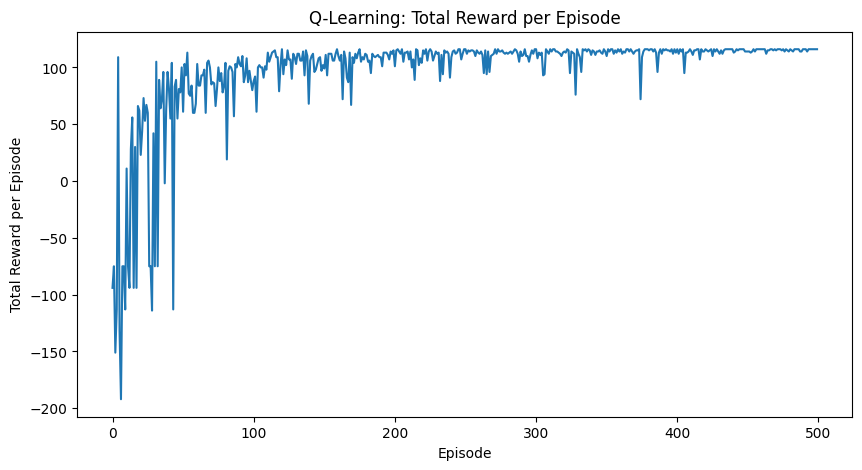

In [ ]:
# Q- Learning: Base Case plot
def reward_plot(q_learning_reward_list):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10,5))
    plt.plot(q_learning_reward_list)
    plt.xlabel("Episode")
    plt.ylabel("Total Reward per Episode")
    plt.title("Q-Learning: Total Reward per Episode")
    plt.show()
reward_plot(q_learning_reward_list)

# Q-Learning: Base Case Epsilon Plot

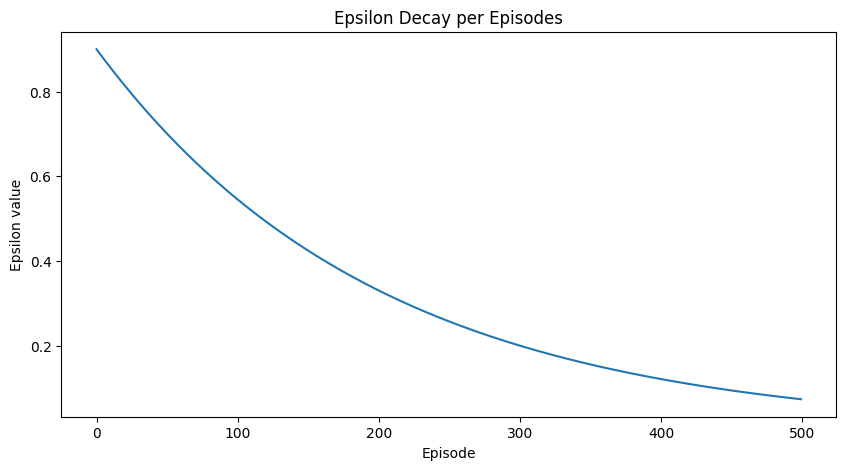

In [ ]:
# Q- Learning
def epsilon_decay_plot(q_learning_epsilon_list):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10,5))
    plt.plot(q_learning_epsilon_list)
    plt.xlabel("Episode")
    plt.ylabel("Epsilon value")
    plt.title("Epsilon Decay per Episodes")
    plt.show()

epsilon_decay_plot(q_learning_epsilon_list)

# Q-Learning: Base Case 10 Episode Greedy Plot

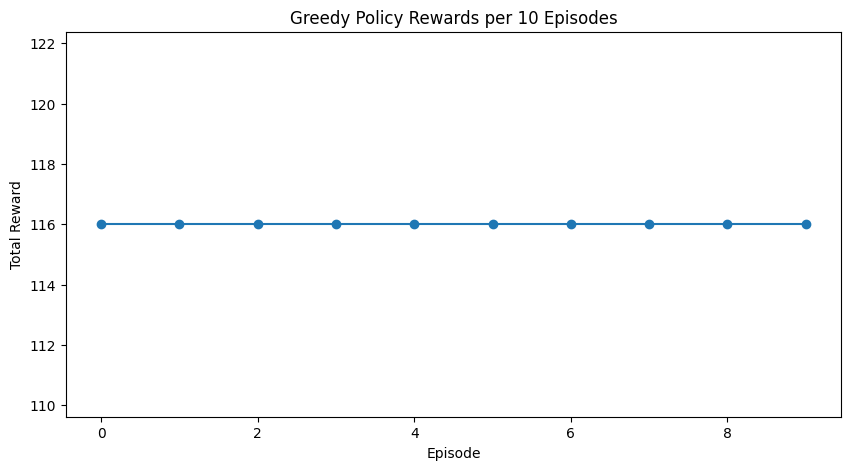

Greedy rewards per episode: [116, 116, 116, 116, 116, 116, 116, 116, 116, 116]


In [ ]:
# Q- Learning (10 episode TEST): Best reward (Greedy way)!
def q_learning_10_episode():
    q_learning_best_reward_list = []

    for ep in range(10):
        obs, info = env.reset()
        state = env.get_state()
        total_reward = 0

        for t in range(env.max_timesteps):
            action = np.argmax(q_table[state, :])
            obs, reward, term, trunc, info = env.step(action)
            state = env.get_state()
            total_reward += reward

            if term or trunc:
                break

        q_learning_best_reward_list.append(total_reward)

    plt.figure(figsize=(10,5))
    plt.plot(q_learning_best_reward_list, marker='o')
    plt.xlabel("Episode")
    plt.ylabel("Total Reward")
    plt.title("Greedy Policy Rewards per 10 Episodes")
    plt.show()

    print("Greedy rewards per episode:", q_learning_best_reward_list)

q_learning_10_episode()

REWARD AT STEP:0: -1 | ACTION: 0 | State: 12


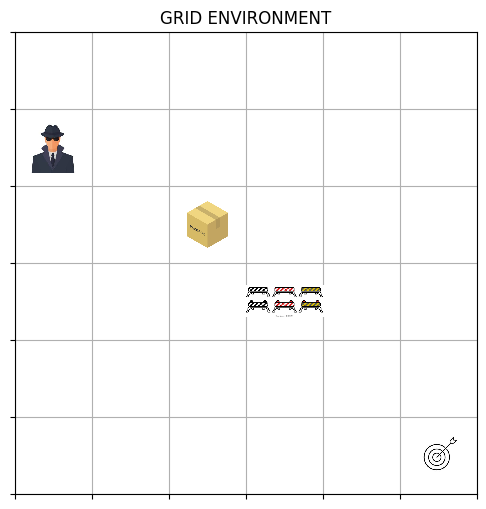

REWARD AT STEP:1: -1 | ACTION: 3 | State: 14


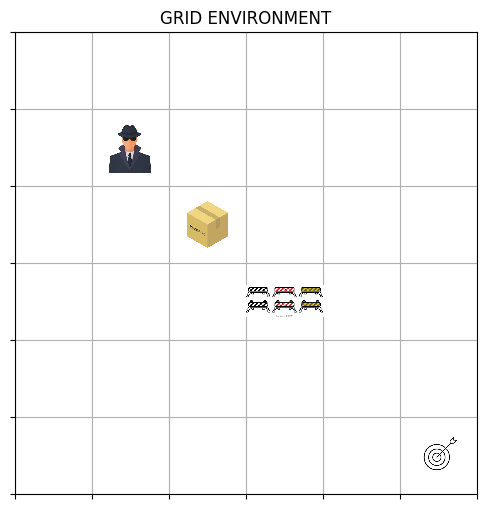

REWARD AT STEP:2: -1 | ACTION: 0 | State: 26


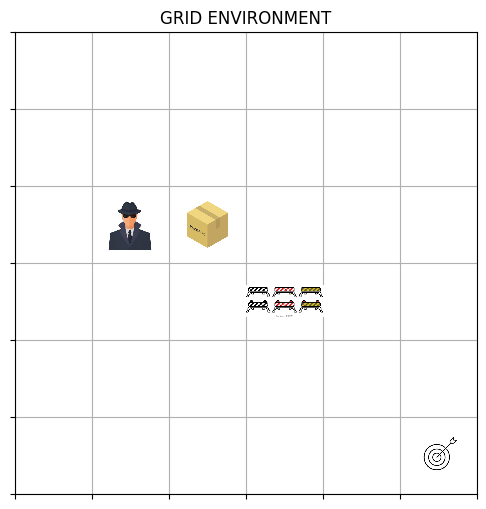

REWARD AT STEP:3: 24 | ACTION: 3 | State: 29


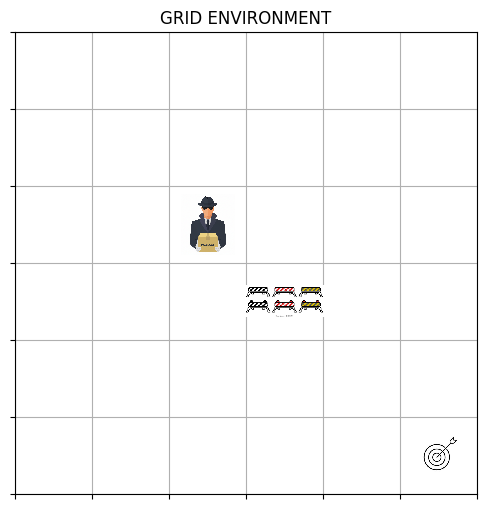

REWARD AT STEP:4: -1 | ACTION: 0 | State: 41


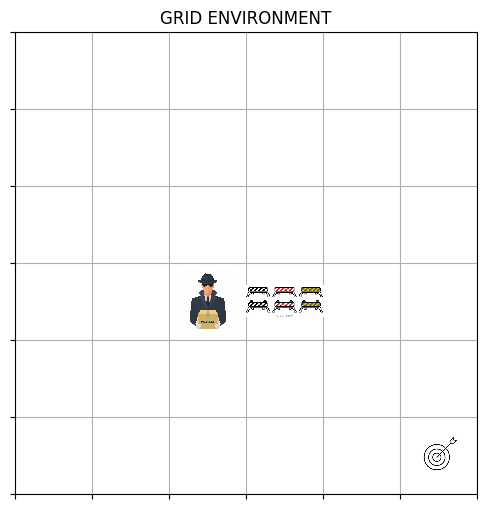

REWARD AT STEP:5: -1 | ACTION: 0 | State: 53


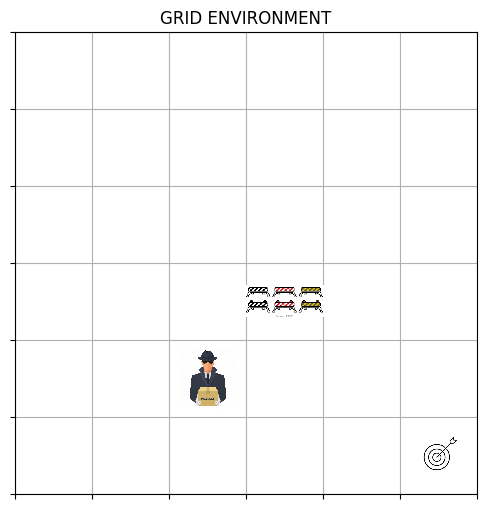

REWARD AT STEP:6: -1 | ACTION: 3 | State: 55


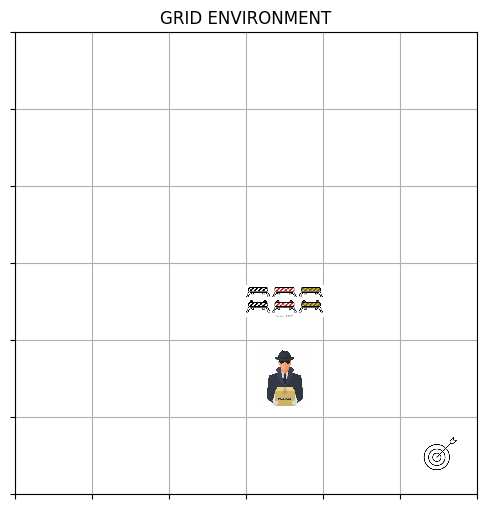

REWARD AT STEP:7: -1 | ACTION: 3 | State: 57


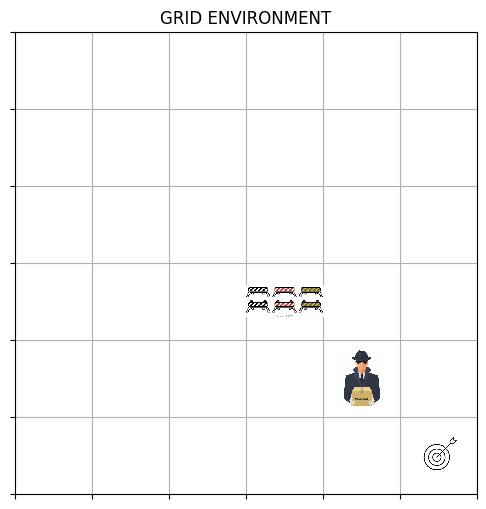

REWARD AT STEP:8: -1 | ACTION: 0 | State: 69


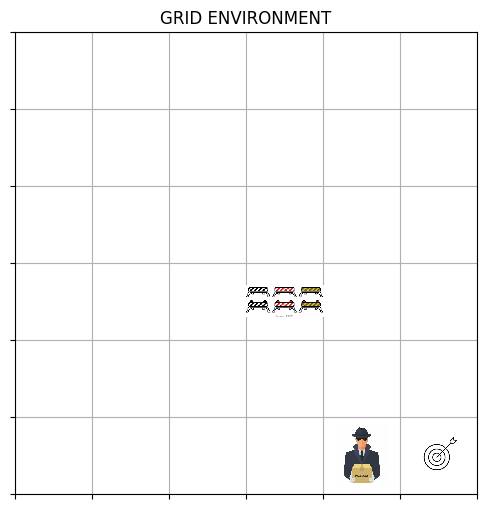

REWARD AT STEP:9: 100 | ACTION: 3 | State: 71


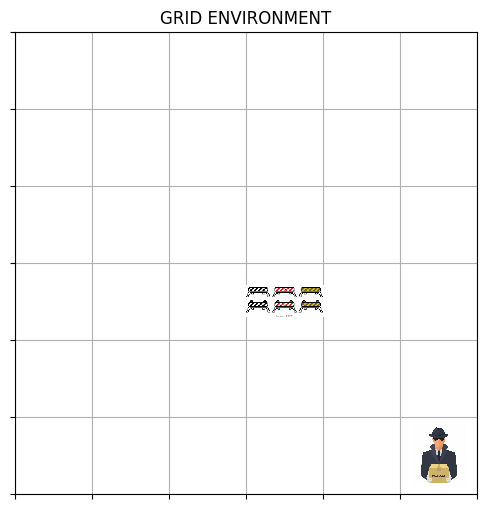

NUMBER OF STEPS TAKEN:9
Total reward for rendered episode: 116


In [ ]:
# Q-Learning (1 TIMESTEP TEST): Best action: MAX TIME STEPS | COUNTING STEPS AND REWARDS!
def q_learning_1_episode():
    obs, info = env.reset()
    state = env.get_state()
    total_reward = 0

    frames = []

    for t in range(env.max_timesteps):
        action = np.argmax(q_table[state, :])
        obs, reward, done, truncated, info = env.step(action)
        state = env.get_state()
        total_reward += reward

        print(f"REWARD AT STEP:{t}: {reward} | ACTION: {action} | State: {state}")
        env.render()

        if done or truncated:
            break
    print(f"NUMBER OF STEPS TAKEN:{t}")
    print(f"Total reward for rendered episode: {total_reward}")

q_learning_1_episode()

In [ ]:
###########################################################################

# SARSA

###########################################################################

In [19]:
#SARSA
def train_sarsa_learning(env, number_of_episodes=3000, alpha=0.1, gamma=0.95, epsilon=0.9, decay=0.995):

    # Get number of states and actions from environment
    number_of_state = len(env.state_to_index_map)
    number_of_actions = env.action_space.n

    sarsa_q_table = np.zeros((number_of_state, number_of_actions))
    print(sarsa_q_table)
    sarsa_rewards_list = []
    sarsa_epsilon_list = []

    for ep in range(number_of_episodes):

        # We always reset env at the start of every episode!!! This is because agent completes one learning step of pick and delivering the package.
        obs, info = env.reset()
        state = env.get_state()
        total_reward = 0
        # We need to iterate till max steps:
        # Then leverage the epsilon greedy approach and pick a random action or the best action.
        # We pass this action to our env step function we created before and get 4/5 things in return like last time.
        # for i in range(max_timesteps)
        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(sarsa_q_table[state, :])


        for t_step in range(env.max_timesteps):

            # Get the next observation, action, reward details! But dont update that as the final next action yet as we need to check in Q-Table frist!!!!
            # obs, r, term, trunc, info
            obs, reward, term, trunc, info = env.step(action)
            # Getting the next state and storing it inside a temp variable for now as we will need it in formula!!
            next_state = env.get_state()


            # explore if random < epsilon
            if np.random.rand() < epsilon:
                next_action = env.action_space.sample()
            else:
                # exploit case
                next_action = np.argmax(sarsa_q_table[state, :])



            # Calculation of the Q-table BUT WE DO NOT TAKE MAX HERE!!!
            target = reward + gamma * sarsa_q_table[next_state, next_action]
            sarsa_q_table[state, action] += alpha * (target - sarsa_q_table[state, action])

            # Now finally update the staet!!
            state = next_state
            action = next_action
            total_reward += reward

            # env.render()

            if term or trunc:
                break

        sarsa_rewards_list.append(total_reward)
        sarsa_epsilon_list.append(epsilon)

        # Decay epsilon
        epsilon *= decay
        if epsilon == 0.0:
            epsilon = 0.05

        if ep % 50 == 0:
            print(f"Episode {ep}, Total reward: {total_reward}, Epsilon: {epsilon:.2f}")
    # print(env.state_to_index_map)
    return sarsa_q_table, sarsa_rewards_list, sarsa_epsilon_list


# SARSA: Base Case Deterministic

In [20]:
# SARSA: Deterministic

env = GridEnv("Deterministic")

env.create_state_dict()
sarsa_q_table, sarsa_rewards_list, sarsa_epsilon_list = train_sarsa_learning(env, number_of_episodes=500, alpha=0.2, gamma=0.95, epsilon=0.9)

[0, 0]
[[0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0

# SARSA: Q-table (Populated)

In [ ]:
import pandas as pd
sarsa_q_table_df = pd.DataFrame(sarsa_q_table)
print("SARSA Q-Table: Deterministic")
# print(pd.DataFrame(q_table))
print(sarsa_q_table_df)
sarsa_zero_df = sarsa_q_table_df[(sarsa_q_table_df == 0).any(axis=1)].copy()
print(sarsa_zero_df)
print(sarsa_zero_df.shape)

SARSA Q-Table: Deterministic
            0          1          2           3          4          5
0    1.838462  11.885573   4.855621   26.675489   7.569387   5.365408
1   -5.386519  -5.238986  -5.290834   -5.393327  -5.281022  -5.373235
2   13.690356   9.225033   6.794656   28.612815  17.511065   7.168067
3   -5.208435  -5.185483  -5.276169   -5.833017  -5.028074  -5.142025
4   58.368041  25.449135   4.414209   25.834687  29.692970  28.005367
..        ...        ...        ...         ...        ...        ...
67  84.184264  46.656239  58.258683   93.955633  81.056336  77.823899
68  -2.448573  -3.480865  -2.408018   -4.719727  -2.661131  -2.246383
69  82.196932  59.078348  74.143389  100.000000  85.769441  80.904959
70  -2.464046  -2.494404  -2.194421   -2.630000  -3.991479  -4.119279
71   0.000000   0.000000   0.000000    0.000000   0.000000   0.000000

[72 rows x 6 columns]
      0    1    2    3    4    5
28  0.0  0.0  0.0  0.0  0.0  0.0
42  0.0  0.0  0.0  0.0  0.0  0.0
43  0.0  

# SARSA: Base Case Reward Plot

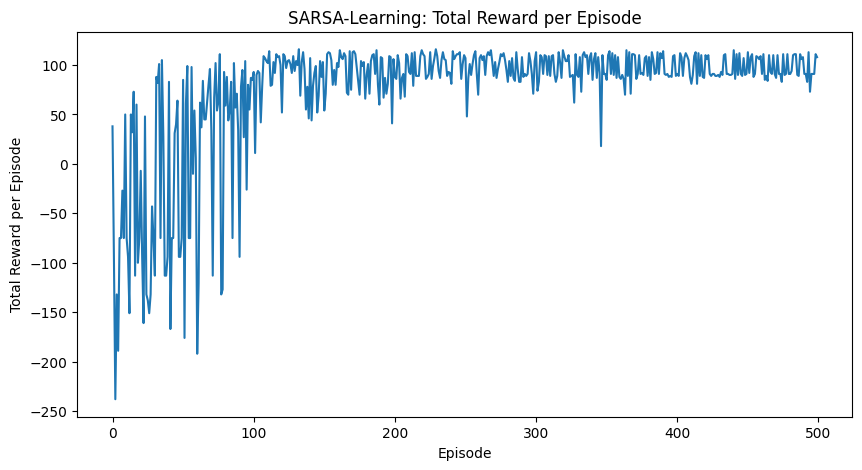

In [ ]:
# SARSA: Plot Deterministic

def reward_plot(sarsa_rewards_list):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10,5))
    plt.plot(sarsa_rewards_list)
    plt.xlabel("Episode")
    plt.ylabel("Total Reward per Episode")
    plt.title("SARSA-Learning: Total Reward per Episode")
    plt.show()
reward_plot(sarsa_rewards_list)

# SARSA: Base Case: Epsilon Plot

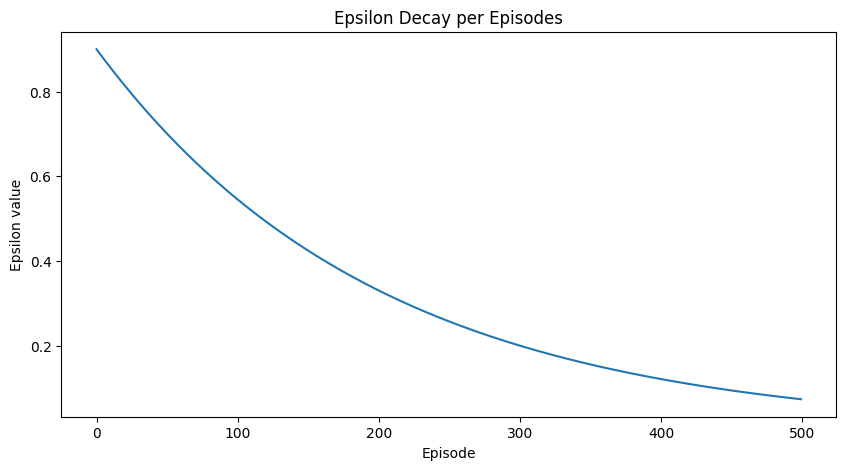

In [ ]:
# SARSA: Plot Epsilon Stochastic
def epsilon_decay_plot(sarsa_epsilon_list):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10,5))
    plt.plot(sarsa_epsilon_list)
    plt.xlabel("Episode")
    plt.ylabel("Epsilon value")
    plt.title("Epsilon Decay per Episodes")
    plt.show()

epsilon_decay_plot(sarsa_epsilon_list)

# SARSA-Learning (10 episode TEST): Best reward (Greedy way)!


[0, 0]


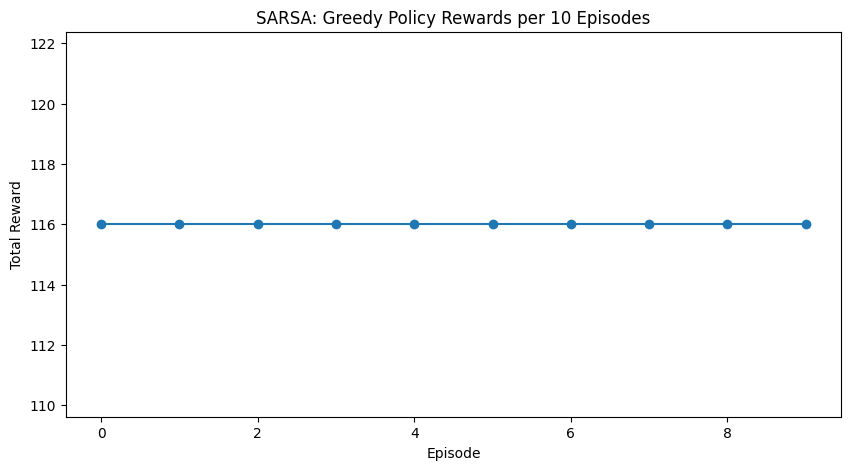

Greedy rewards per episode: [116, 116, 116, 116, 116, 116, 116, 116, 116, 116]


In [ ]:
def sarsa_learning_10_episode():
    sarsa_learning_best_reward_list = []

    for ep in range(10):
        obs, info = env.reset()
        state = env.get_state()
        total_reward = 0

        for t in range(env.max_timesteps):
            action = np.argmax(sarsa_q_table[state, :])
            obs, reward, term, trunc, info = env.step(action)
            state = env.get_state()
            total_reward += reward

            if term or trunc:
                break

        sarsa_learning_best_reward_list.append(total_reward)

    plt.figure(figsize=(10,5))
    plt.plot(sarsa_learning_best_reward_list, marker='o')
    plt.xlabel("Episode")
    plt.ylabel("Total Reward")
    plt.title("SARSA: Greedy Policy Rewards per 10 Episodes")
    plt.show()

    print("Greedy rewards per episode:", sarsa_learning_best_reward_list)

env = GridEnv("Deterministic")
env.create_state_dict()
sarsa_learning_10_episode()

# SARSA: (1 TIMESTEP TEST): Best action: MAX TIME STEPS | COUNTING STEPS AND REWARDS!


[0, 0]
REWARD AT STEP:0: -1 | ACTION: 3 | State: 2


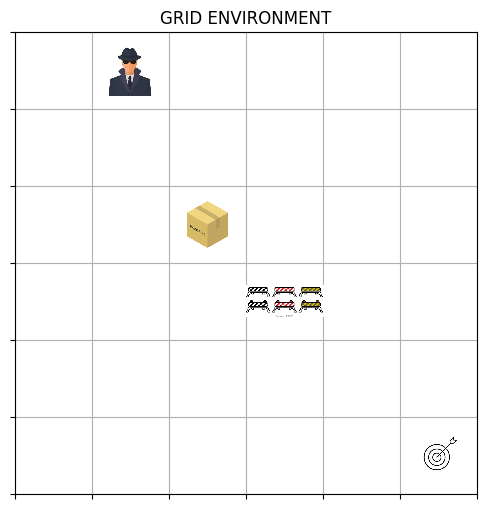

REWARD AT STEP:1: -1 | ACTION: 3 | State: 4


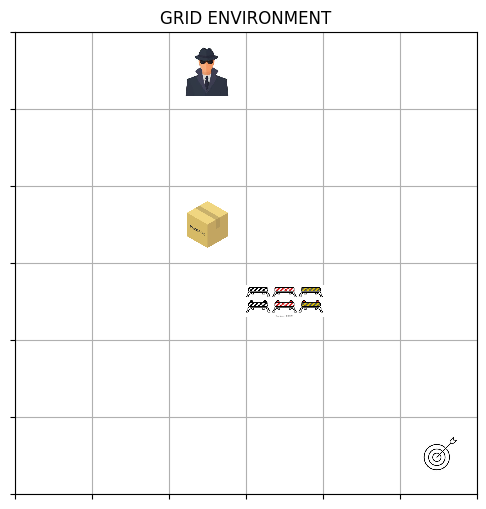

REWARD AT STEP:2: -1 | ACTION: 0 | State: 16


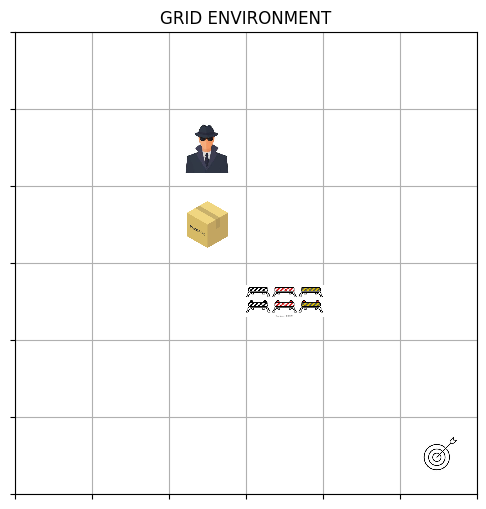

REWARD AT STEP:3: 24 | ACTION: 0 | State: 29


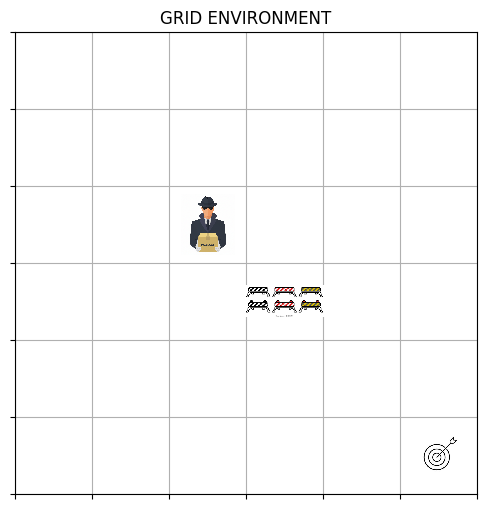

REWARD AT STEP:4: -1 | ACTION: 0 | State: 41


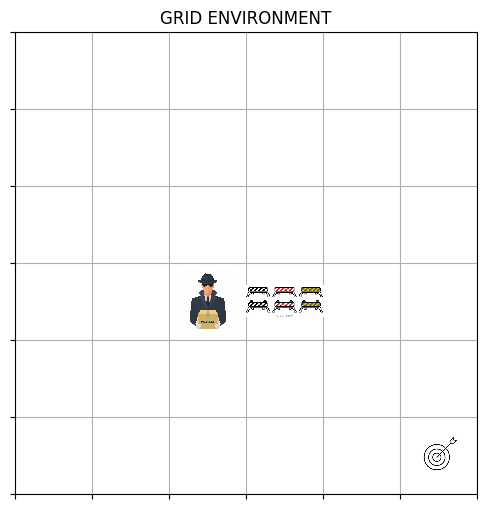

REWARD AT STEP:5: -1 | ACTION: 0 | State: 53


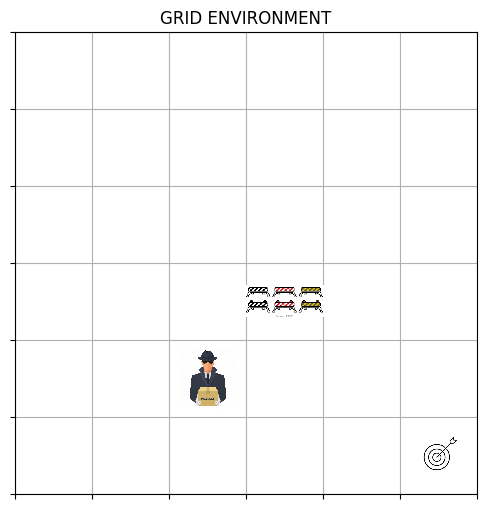

REWARD AT STEP:6: -1 | ACTION: 0 | State: 65


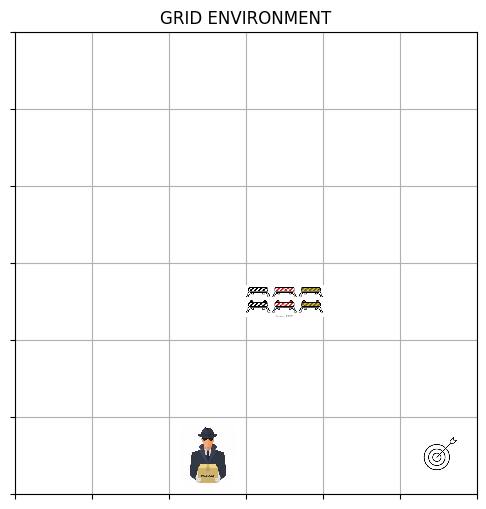

REWARD AT STEP:7: -1 | ACTION: 3 | State: 67


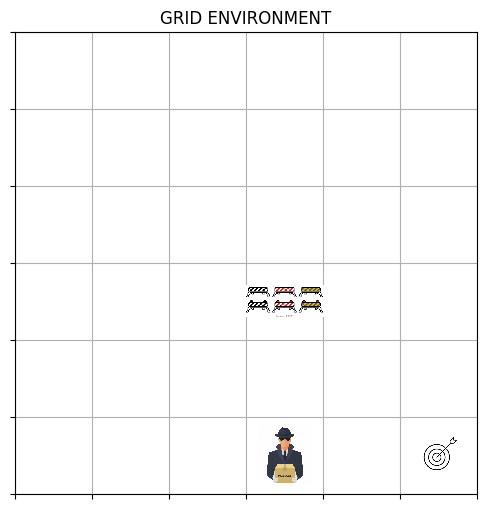

REWARD AT STEP:8: -1 | ACTION: 3 | State: 69


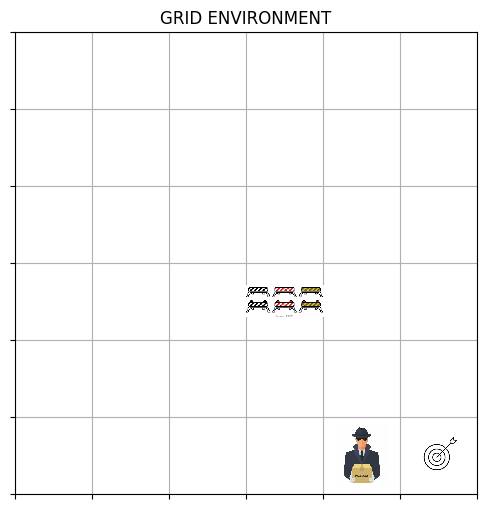

REWARD AT STEP:9: 100 | ACTION: 3 | State: 71


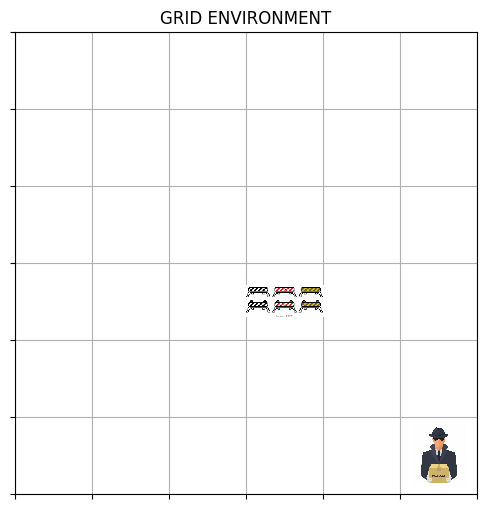

NUMBER OF STEPS TAKEN:9
Total reward for rendered episode: 116


In [ ]:
def sarsa_learning_1_episode():
    obs, info = env.reset()
    state = env.get_state()
    total_reward = 0

    frames = []

    for t in range(env.max_timesteps):
        action = np.argmax(sarsa_q_table[state, :])
        obs, reward, term, trunc, info = env.step(action)
        state = env.get_state()
        total_reward += reward

        print(f"REWARD AT STEP:{t}: {reward} | ACTION: {action} | State: {state}")
        env.render()

        if term or trunc:
            break
    print(f"NUMBER OF STEPS TAKEN:{t}")
    print(f"Total reward for rendered episode: {total_reward}")

env = GridEnv("Deterministic")
env.create_state_dict()

sarsa_learning_1_episode()

# Deterministic: Q-Learning vs SARSA Combined Reward Comparison

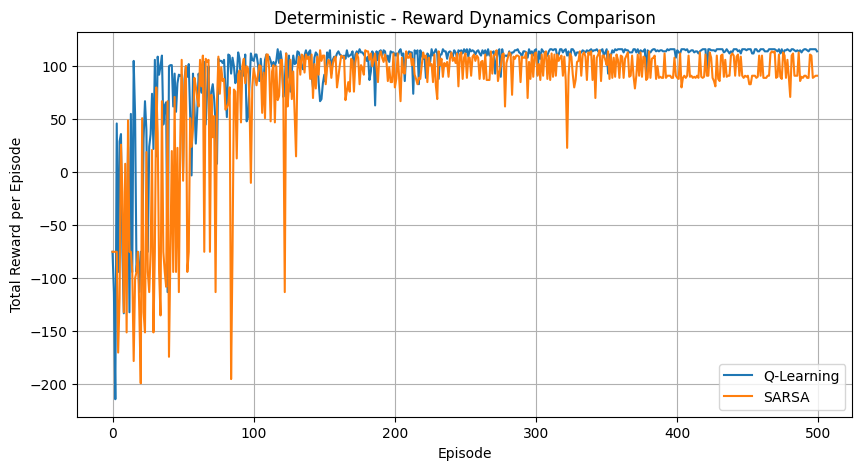

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(q_learning_reward_list, label="Q-Learning")
plt.plot(sarsa_rewards_list, label="SARSA")

plt.xlabel("Episode")
plt.ylabel("Total Reward per Episode")
plt.title("Deterministic - Reward Dynamics Comparison")
plt.legend()
plt.grid(True)

plt.show()


# ======================Q-Learning & SARSA Deterministic Run ends here======================

In [ ]:
# ============================================SARSA: Stochastic============================================

# ==============SARSA: Stochastic============

In [ ]:
env = GridEnv("Stochastic")

env.create_state_dict()
sarsa_q_table, sarsa_rewards_list, sarsa_epsilon_list = train_sarsa_learning(env, number_of_episodes=500, alpha=0.2, gamma=0.95, epsilon=0.9)

[0, 0]
Episode 0, Total reward: 95, Epsilon: 0.90
Episode 50, Total reward: -94, Epsilon: 0.70
Episode 100, Total reward: 85, Epsilon: 0.54
Episode 150, Total reward: 103, Epsilon: 0.42
Episode 200, Total reward: 86, Epsilon: 0.33
Episode 250, Total reward: 106, Epsilon: 0.26
Episode 300, Total reward: 106, Epsilon: 0.20
Episode 350, Total reward: 88, Epsilon: 0.15
Episode 400, Total reward: 105, Epsilon: 0.12
Episode 450, Total reward: 91, Epsilon: 0.09


In [ ]:
import pandas as pd
sarsa_q_table_df = pd.DataFrame(sarsa_q_table)
# print(pd.DataFrame(q_table))
print(sarsa_q_table_df)
sarsa_zero_df = sarsa_q_table_df[(sarsa_q_table_df == 0).any(axis=1)].copy()
print("SARSA Q-Table: Stochastic: Filtered")
print(sarsa_zero_df)
print(sarsa_zero_df.shape)

            0          1          2          3          4          5
0   19.282749   5.668291   5.018348  10.465840   7.929897   0.606160
1   -5.449503  -5.289950  -5.328564  -5.003887  -5.006513  -5.019415
2   17.839062  -0.303259  -2.556827   1.289678   0.089544  -1.264104
3   -5.047847  -4.353904  -5.294908  -5.329801  -4.041412  -4.591429
4    8.314282  -1.536043  -0.062825  -0.397079   2.945100   0.347694
..        ...        ...        ...        ...        ...        ...
67  65.738188  19.542209  24.455031  83.822648  45.780550  56.403531
68  -1.178339  -0.360000  -1.395593  -4.670081  -0.902818  -1.217919
69  68.076558  39.002541  47.432658  99.995074  77.841166  80.691867
70  -6.090214  -2.079062  -1.139900  -1.800000  -3.929765  -6.030354
71   0.000000   0.000000   0.000000   0.000000   0.000000   0.000000

[72 rows x 6 columns]
SARSA Q-Table: Stochastic: Filtered
      0    1    2    3    4    5
28  0.0  0.0  0.0  0.0  0.0  0.0
42  0.0  0.0  0.0  0.0  0.0  0.0
43  0.0  0.0  

#SARSA: Reward Plot

SARSA: Stochastic: Reward Graph


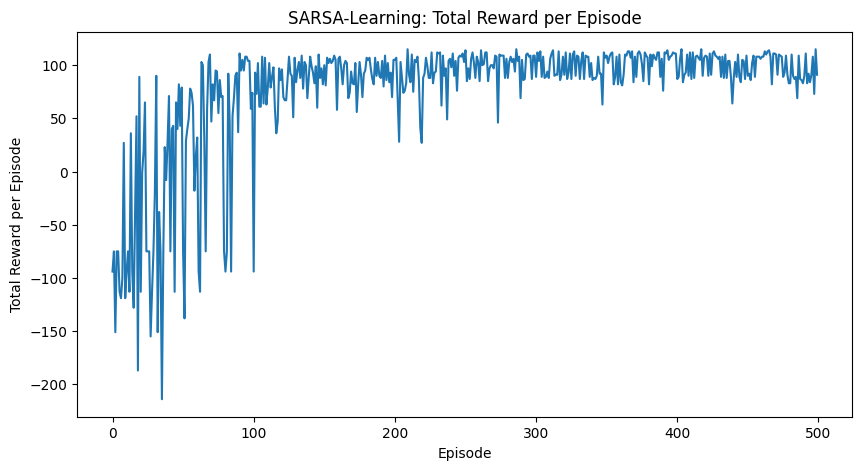

In [ ]:
# SARSA:

def reward_plot(sarsa_rewards_list):
    import matplotlib.pyplot as plt
    print("SARSA: Stochastic: Reward Graph")
    plt.figure(figsize=(10,5))
    plt.plot(sarsa_rewards_list)
    plt.xlabel("Episode")
    plt.ylabel("Total Reward per Episode")
    plt.title("SARSA-Learning: Total Reward per Episode")
    plt.show()
reward_plot(sarsa_rewards_list)

# SARSA: Epsilon Plot

SARSA: Stochastic: Epsilon Graph!


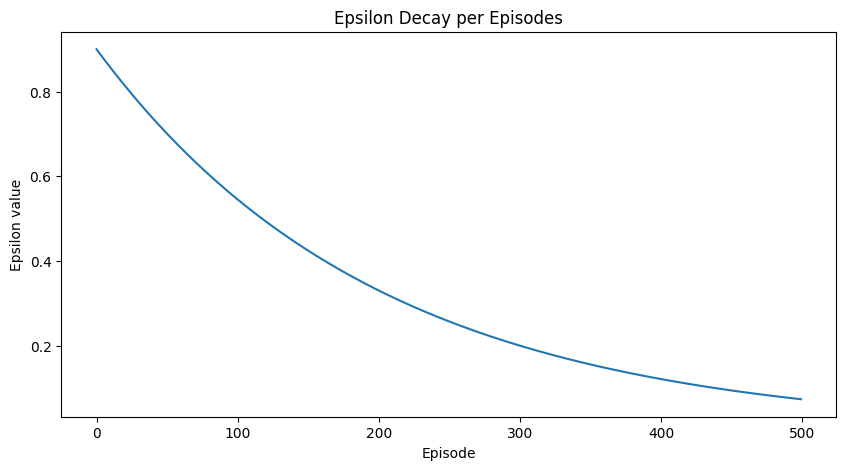

In [ ]:
# SARSA:
def epsilon_decay_plot(sarsa_epsilon_list):
    import matplotlib.pyplot as plt
    print("SARSA: Stochastic: Epsilon Graph!")
    plt.figure(figsize=(10,5))
    plt.plot(sarsa_epsilon_list)
    plt.xlabel("Episode")
    plt.ylabel("Epsilon value")
    plt.title("Epsilon Decay per Episodes")
    plt.show()

epsilon_decay_plot(sarsa_epsilon_list)

# # SARSA-Stochastic (10 episode TEST): Best reward (Greedy way)!


[0, 0]


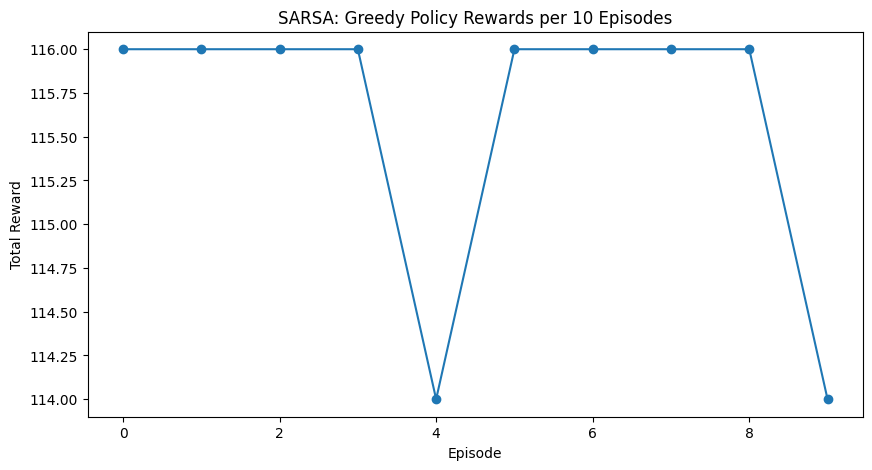

Greedy rewards per episode: [116, 116, 116, 116, 114, 116, 116, 116, 116, 114]


In [ ]:
# SARSA-Learning (10 episode TEST): Best reward (Greedy way)!
def sarsa_learning_10_episode():
    sarsa_learning_best_reward_list = []

    for ep in range(10):
        obs, info = env.reset()
        state = env.get_state()
        total_reward = 0

        for t in range(env.max_timesteps):
            action = np.argmax(sarsa_q_table[state, :])
            obs, reward, term, trunc, info = env.step(action)
            state = env.get_state()
            total_reward += reward

            if term or trunc:
                break

        sarsa_learning_best_reward_list.append(total_reward)

    plt.figure(figsize=(10,5))
    plt.plot(sarsa_learning_best_reward_list, marker='o')
    plt.xlabel("Episode")
    plt.ylabel("Total Reward")
    plt.title("SARSA: Greedy Policy Rewards per 10 Episodes")
    plt.show()

    print("Greedy rewards per episode:", sarsa_learning_best_reward_list)
env = GridEnv("Stochastic")
env.create_state_dict()

sarsa_learning_10_episode()

# SARSA: Stochastic: (1 TIMESTEP TEST): Best action: MAX TIME STEPS | COUNTING STEPS AND REWARDS!


[0, 0]
REWARD AT STEP:0: -1 | ACTION: 0 | State: 12


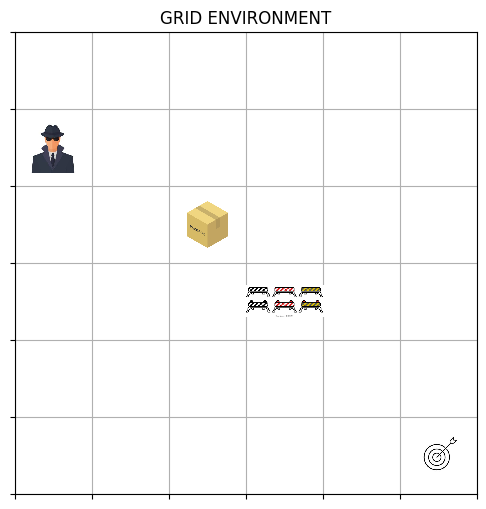

REWARD AT STEP:1: -1 | ACTION: 0 | State: 24


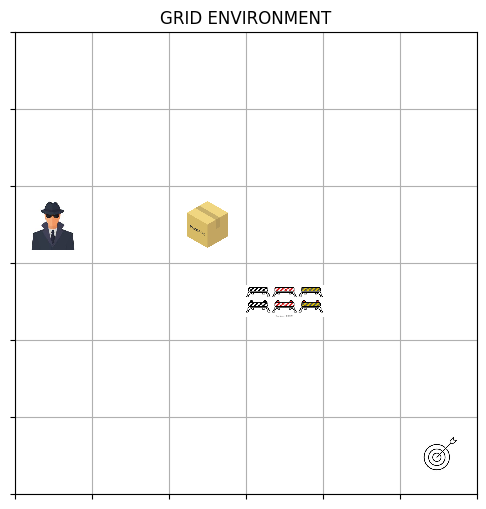

REWARD AT STEP:2: -1 | ACTION: 3 | State: 26


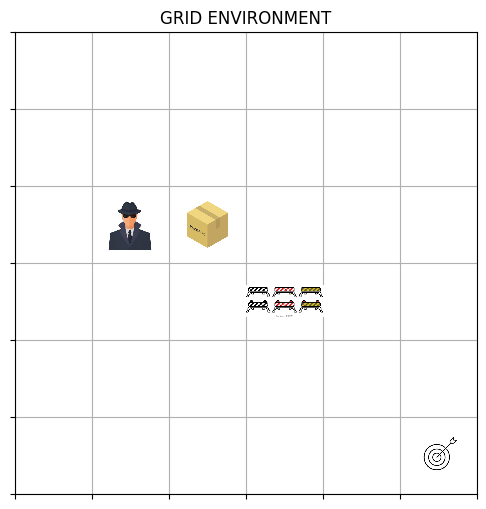

REWARD AT STEP:3: 24 | ACTION: 3 | State: 29


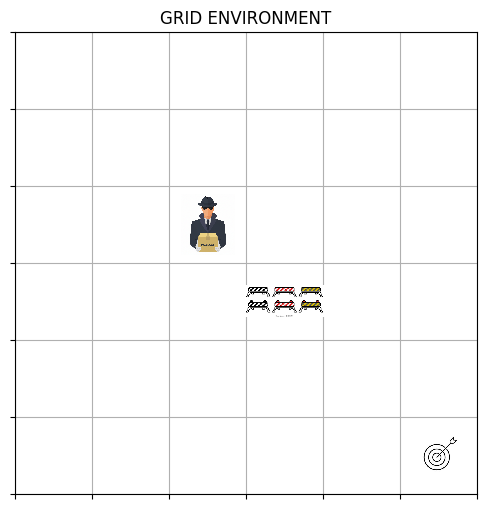

REWARD AT STEP:4: -1 | ACTION: 3 | State: 31


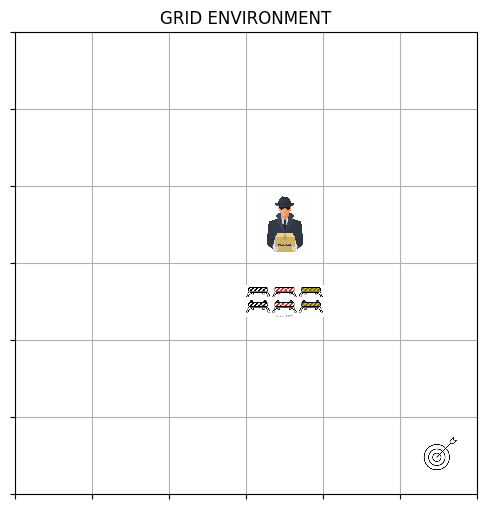

REWARD AT STEP:5: -1 | ACTION: 3 | State: 33


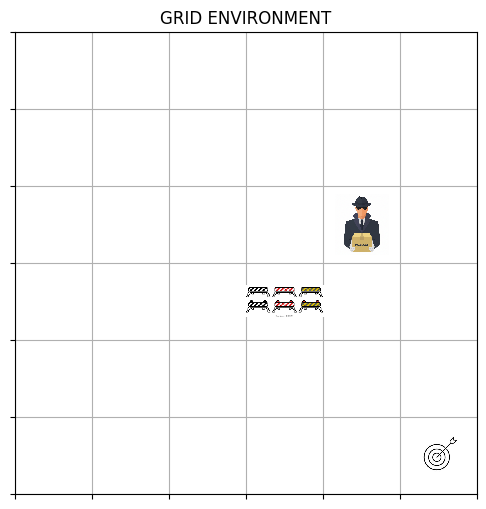

REWARD AT STEP:6: -1 | ACTION: 3 | State: 35


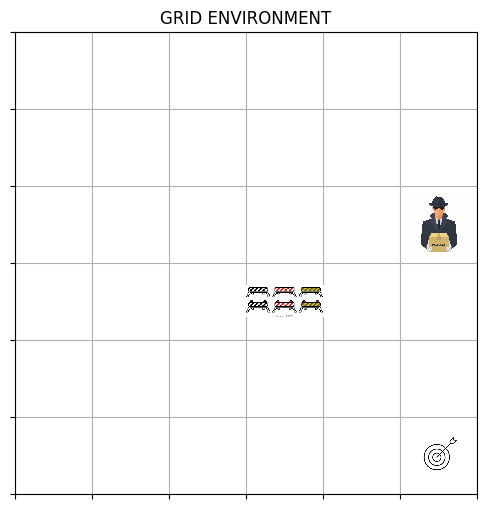

REWARD AT STEP:7: -1 | ACTION: 0 | State: 47


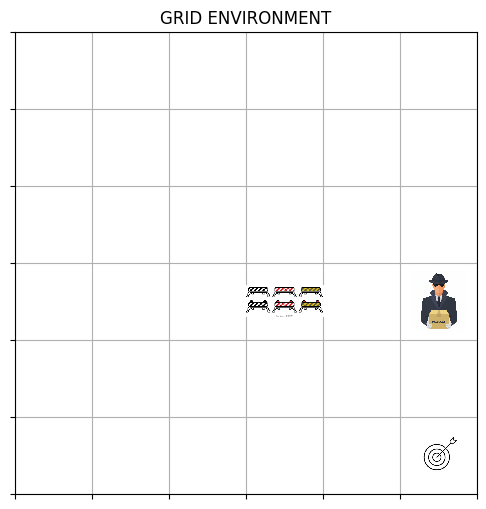

REWARD AT STEP:8: -1 | ACTION: 0 | State: 59


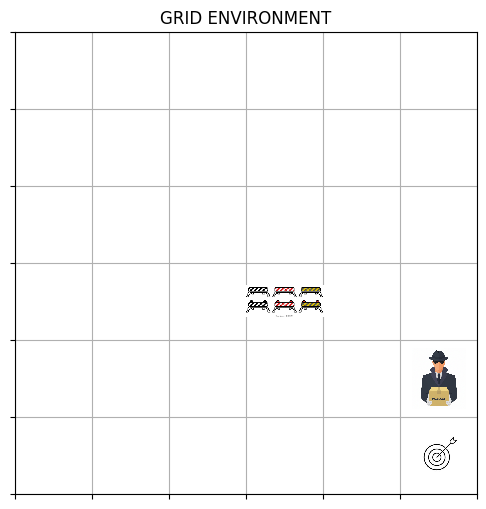

REWARD AT STEP:9: 100 | ACTION: 0 | State: 71


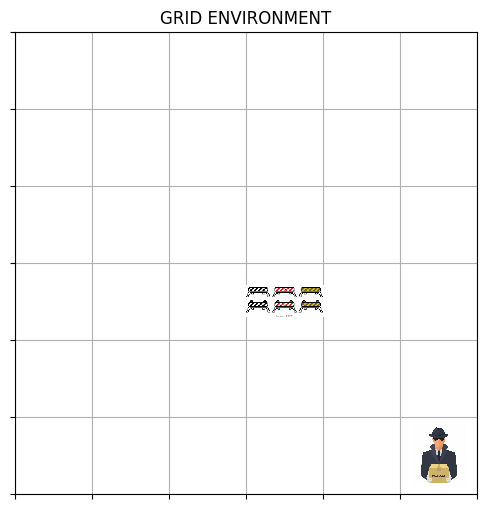

NUMBER OF STEPS TAKEN:9
Total reward for rendered episode: 116


In [ ]:
# SARSA-Learning (1 TIMESTEP TEST): Best action: MAX TIME STEPS | COUNTING STEPS AND REWARDS!
def sarsa_learning_1_episode():
    obs, info = env.reset()
    state = env.get_state()
    total_reward = 0

    frames = []

    for t in range(env.max_timesteps):
        action = np.argmax(sarsa_q_table[state, :])
        obs, reward, term, trunc, info = env.step(action)
        state = env.get_state()
        total_reward += reward

        print(f"REWARD AT STEP:{t}: {reward} | ACTION: {action} | State: {state}")
        env.render()

        if term or trunc:
            break
    print(f"NUMBER OF STEPS TAKEN:{t}")
    print(f"Total reward for rendered episode: {total_reward}")

env = GridEnv("Stochastic")
env.create_state_dict()
sarsa_learning_1_episode()

# Q-Learning: Stochastic Implementation

In [ ]:


env = GridEnv("Stochastic")
env.create_state_dict()
q_table, q_learning_reward_list, q_learning_epsilon_list = train_q_learning(env, number_of_episodes=500, alpha=0.2, gamma=0.95, epsilon=0.9)


[0, 0]
Episode 0, Total reward: -75, Epsilon: 0.90
Episode 50, Total reward: -9, Epsilon: 0.70
Episode 100, Total reward: 88, Epsilon: 0.54
Episode 150, Total reward: 103, Epsilon: 0.42
Episode 200, Total reward: 112, Epsilon: 0.33
Episode 250, Total reward: 115, Epsilon: 0.26
Episode 300, Total reward: 104, Epsilon: 0.20
Episode 350, Total reward: 114, Epsilon: 0.15
Episode 400, Total reward: 94, Epsilon: 0.12
Episode 450, Total reward: 115, Epsilon: 0.09


# Q-Learning: Stochastic: Q-Table

In [ ]:
import pandas as pd
q_table_df = pd.DataFrame(q_table)
# print(pd.DataFrame(q_table))
print(q_table_df)
zero_df = q_table_df[(q_table_df == 0).any(axis=1)].copy()
print(zero_df)
print(zero_df.shape)


            0          1          2          3          4          5
0   75.115529  69.905510  70.039279  72.475666  69.411513  69.202810
1   -1.821670  -1.870743  -2.012903  -1.823584  -1.885799  -2.092842
2   78.501129  52.592784  48.648133  13.592266  31.431649  32.627703
3    4.860218  -1.332560  -1.789164  -1.411900  -1.448000  -1.465485
4   64.541342  10.010933   1.731545  13.632010   6.929614   8.267025
..        ...        ...        ...        ...        ...        ...
67  37.275417  19.476645  11.402596  91.467743  22.828991  17.290601
68  -0.200000  -0.488000  -0.238000  -1.000000  -0.765040  -0.590400
69  62.792267  67.690703  43.446078  99.599655  52.887308  78.069316
70   0.000000   0.000000  -0.238000   0.000000   0.000000  -1.000000
71   0.000000   0.000000   0.000000   0.000000   0.000000   0.000000

[72 rows x 6 columns]
           0          1         2      3         4         5
8  -0.200000  -0.200000 -0.215124 -0.360  0.000000  0.000000
20 -0.200000   1.634937  9.

# Q-Learning: Stochastic: Base Case Plot

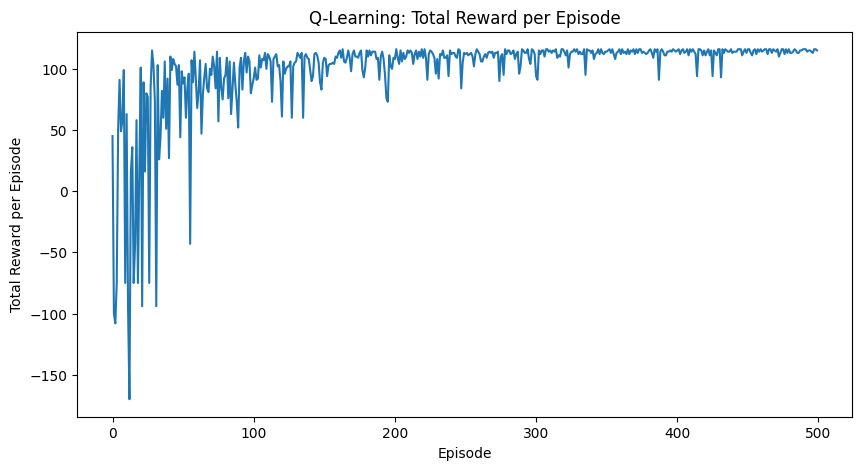

In [ ]:
# Q- Learning: Base Case plot
def reward_plot(q_learning_reward_list):
   import matplotlib.pyplot as plt


   plt.figure(figsize=(10,5))
   plt.plot(q_learning_reward_list)
   plt.xlabel("Episode")
   plt.ylabel("Total Reward per Episode")
   plt.title("Q-Learning: Total Reward per Episode")
   plt.show()
reward_plot(q_learning_reward_list)

# Q-Learning: Stochastic: Epsilon Plot

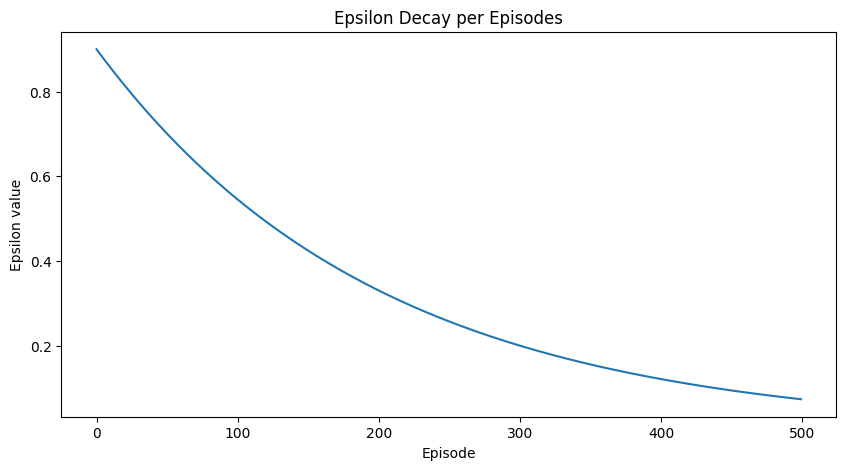

In [ ]:
# Q- Learning: Stochastic
def epsilon_decay_plot(q_learning_epsilon_list):
   import matplotlib.pyplot as plt


   plt.figure(figsize=(10,5))
   plt.plot(q_learning_epsilon_list)
   plt.xlabel("Episode")
   plt.ylabel("Epsilon value")
   plt.title("Epsilon Decay per Episodes")
   plt.show()


epsilon_decay_plot(q_learning_epsilon_list)


# Q-Learning: Stochastic: (10 episode TEST): Best reward (Greedy way)!

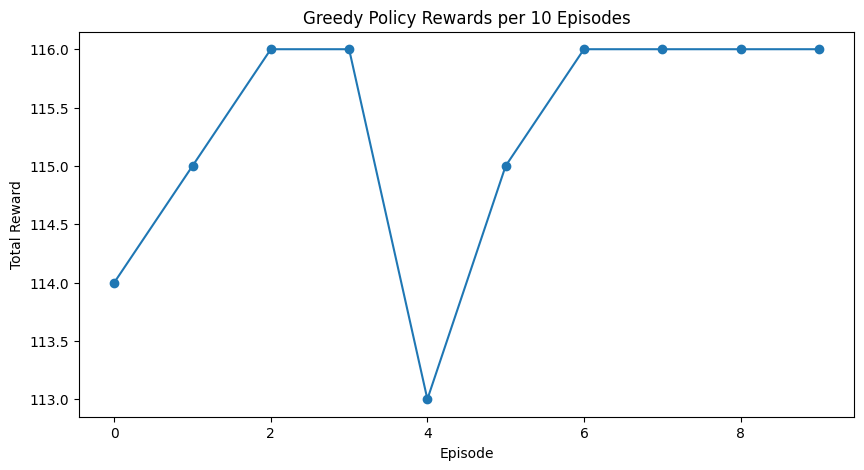

Greedy rewards per episode: [114, 115, 116, 116, 113, 115, 116, 116, 116, 116]


In [ ]:
# Q- Learning (10 episode TEST): Best reward (Greedy way)!
def q_learning_10_episode():
   q_learning_best_reward_list = []


   for ep in range(10):
       obs, info = env.reset()
       state = env.get_state()
       total_reward = 0


       for t in range(env.max_timesteps):
           action = np.argmax(q_table[state, :])
           obs, reward, term, trunc, info = env.step(action)
           state = env.get_state()
           total_reward += reward


           if term or trunc:
               break


       q_learning_best_reward_list.append(total_reward)


   plt.figure(figsize=(10,5))
   plt.plot(q_learning_best_reward_list, marker='o')
   plt.xlabel("Episode")
   plt.ylabel("Total Reward")
   plt.title("Greedy Policy Rewards per 10 Episodes")
   plt.show()


   print("Greedy rewards per episode:", q_learning_best_reward_list)


q_learning_10_episode()

# Q-Learning: Stochastic: (1 TIMESTEP TEST): Best action: MAX TIME STEPS | COUNTING STEPS AND REWARDS!


REWARD AT STEP:0: -1 | ACTION: 0 | State: 12


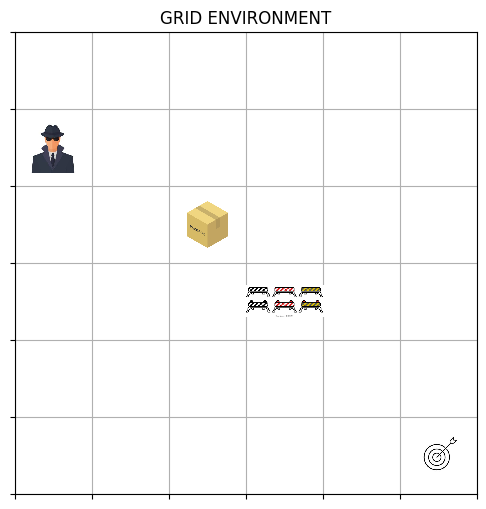

REWARD AT STEP:1: -1 | ACTION: 0 | State: 24


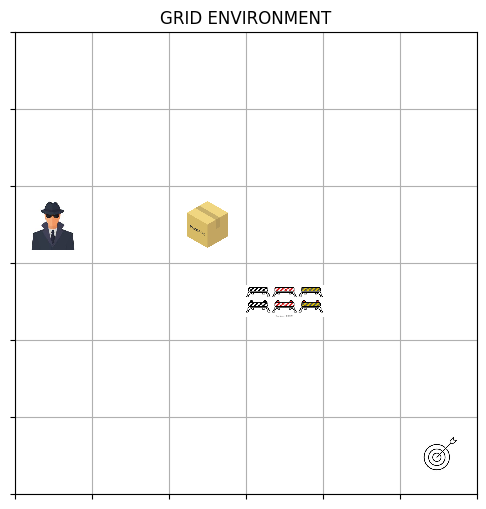

REWARD AT STEP:2: -1 | ACTION: 3 | State: 26


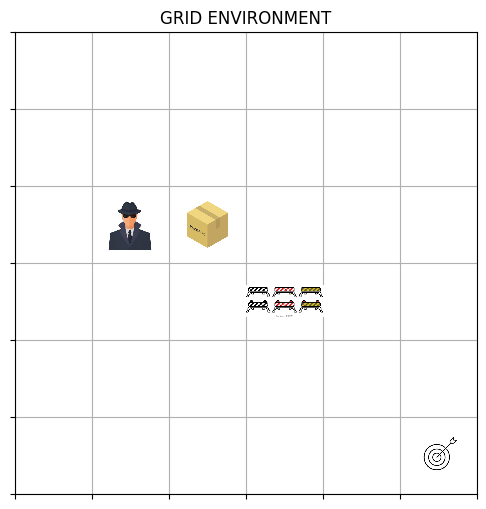

REWARD AT STEP:3: 24 | ACTION: 3 | State: 29


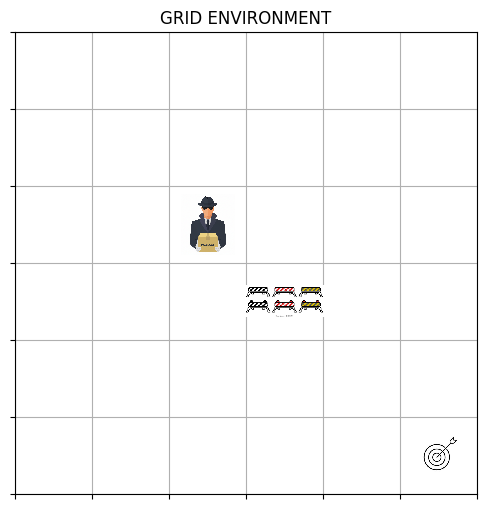

REWARD AT STEP:4: -1 | ACTION: 3 | State: 31


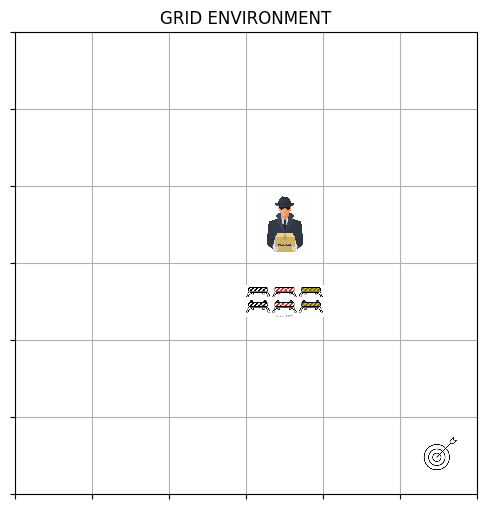

REWARD AT STEP:5: -1 | ACTION: 3 | State: 33


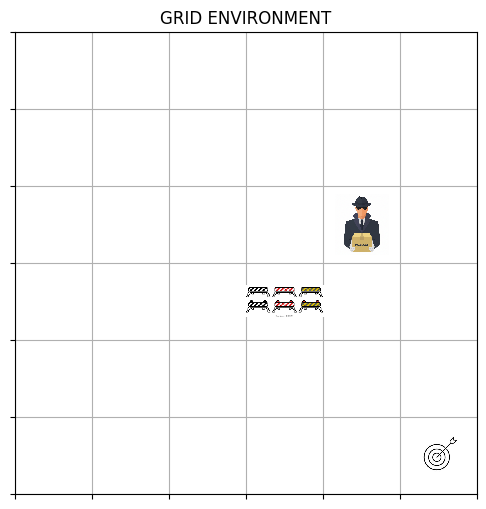

REWARD AT STEP:6: -1 | ACTION: 3 | State: 35


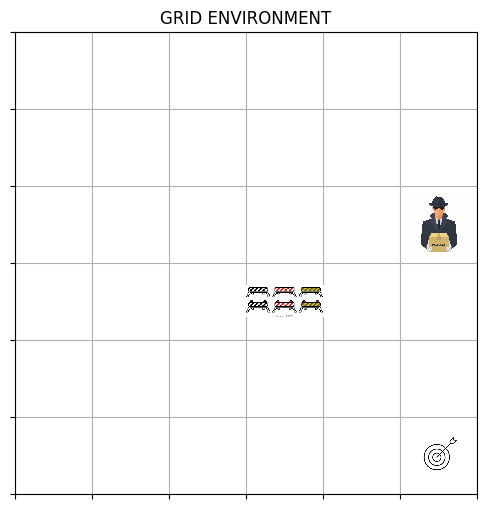

REWARD AT STEP:7: -1 | ACTION: 0 | State: 47


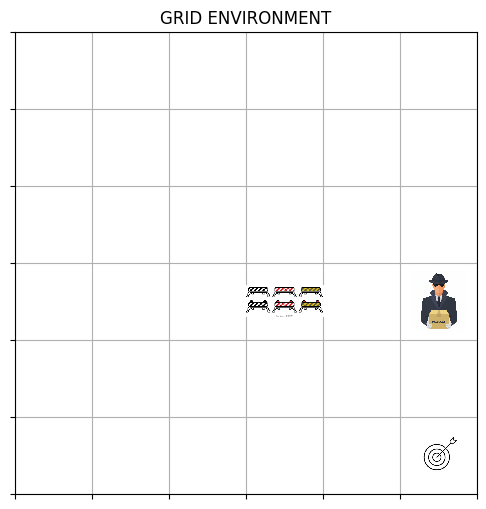

REWARD AT STEP:8: -1 | ACTION: 0 | State: 59


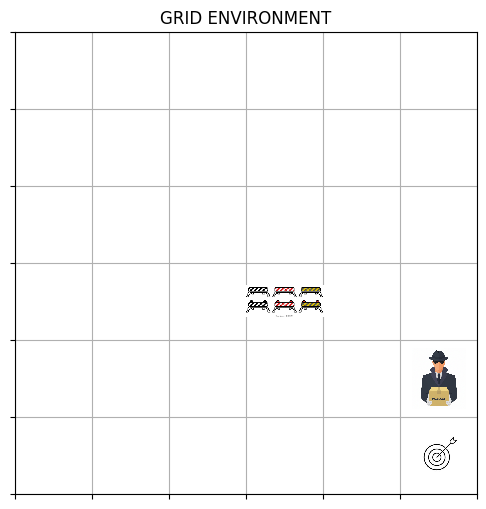

REWARD AT STEP:9: 100 | ACTION: 0 | State: 71


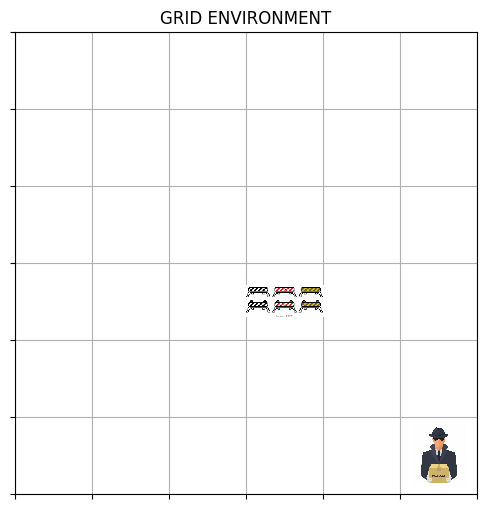

NUMBER OF STEPS TAKEN:9
Total reward for rendered episode: 116


In [ ]:
# Q-Learning: Stochastic: (1 TIMESTEP TEST): Best action: MAX TIME STEPS | COUNTING STEPS AND REWARDS!
def q_learning_1_episode():
   obs, info = env.reset()
   state = env.get_state()
   total_reward = 0


   frames = []


   for t in range(env.max_timesteps):
       action = np.argmax(q_table[state, :])
       obs, reward, term, trunc, info = env.step(action)
       state = env.get_state()
       total_reward += reward


       print(f"REWARD AT STEP:{t}: {reward} | ACTION: {action} | State: {state}")
       env.render()


       if term or trunc:
           break
   print(f"NUMBER OF STEPS TAKEN:{t}")
   print(f"Total reward for rendered episode: {total_reward}")


q_learning_1_episode()

In [ ]:
###############################################################################################

# HYPERPARAMETER TUNING AND RESULT STORING FOR EACH ALGO:

###############################################################################################

In [ ]:
# HYPERPARAMETER TUNING:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os


def hyperparameter_tuning(env, algo, episodes_list, epsilon_decay_list, alpha=0.1, gamma=0.95):

    best_total_reward = -np.inf
    best_q_table = None
    best_hyperparams = None

    results_summary = []

    for num_episodes in episodes_list:
        for epsilon_decay in epsilon_decay_list:

            if algo == "Q-learning":
                q_table, rewards_list, epsilon_list = train_q_learning(env, number_of_episodes=num_episodes, alpha=alpha, gamma=gamma, epsilon=0.9)

            elif algo == "SARSA":
                q_table, rewards_list, epsilon_list = train_sarsa_learning(env, number_of_episodes=num_episodes, alpha=alpha, gamma=gamma, epsilon=0.9)

            greedy_rewards = []
            for ep in range(10):
                obs, info = env.reset()
                state = env.get_state()
                total_reward = 0
                for t in range(env.max_timesteps):
                    action = np.argmax(q_table[state, :])
                    obs, reward, term, trunc, info = env.step(action)
                    state = env.get_state()
                    total_reward += reward
                    if term or trunc:
                        break
                greedy_rewards.append(total_reward)

            # prnit(max_reward)
            max_reward = max(greedy_rewards)

            if max_reward > best_total_reward:
                best_total_reward = max_reward
                best_q_table = q_table
                best_hyperparams = {"num_episodes": num_episodes, "epsilon_decay": epsilon_decay}

            results_summary.append({"algo": algo, "num_episodes": num_episodes, "epsilon_decay": epsilon_decay, "avg_greedy_reward": max_reward})

            print(f"{algo}: Episodes: {num_episodes} | Epsilon decay: {epsilon_decay} | MAX reward: {max_reward}")

    # Saving the best Q-table
    save_path = f"models/{algo}_best_q_table.pkl"
    with open(save_path, "wb") as f:
        pickle.dump(best_q_table, f)
    print(f"Best {algo} Q-table saved to: {save_path}")
    print("Best hyperparameters:", best_hyperparams)
    print("########################################\n")


    return results_summary, best_q_table, best_hyperparams


# Stochastic: Q-Learning vs SARSA Combined Reward Comparison

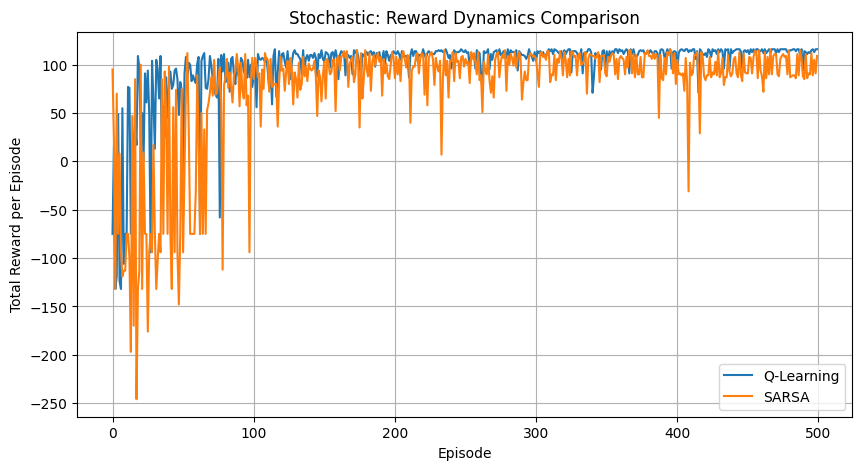

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(q_learning_reward_list, label="Q-Learning")
plt.plot(sarsa_rewards_list, label="SARSA")

plt.xlabel("Episode")
plt.ylabel("Total Reward per Episode")
plt.title("Stochastic: Reward Dynamics Comparison")
plt.legend()
plt.grid(True)

plt.show()


In [ ]:
episodes_to_try = [350, 700, 1000]
epsilon_decay_to_try = [0.99, 0.995, 0.97]



# Experiment:1

In [ ]:
# Experiment:1
# Q-Learning tuning: Hyperparameter 1: # of Episodes.
# Allowed values are: [350, 700, 1000].
# Rest of the parameters will be kept constant
env = GridEnv("Deterministic")
env.create_state_dict()
episodes_to_try = [350]
ql_results, ql_best_q_table, ql_best_hyper = hyperparameter_tuning(env, "Q-learning", episodes_to_try, [0.995])


[0, 0]
Episode 0, Total reward: 89, Epsilon: 0.90
Episode 50, Total reward: 104, Epsilon: 0.70
Episode 100, Total reward: 92, Epsilon: 0.54
Episode 150, Total reward: 112, Epsilon: 0.42
Episode 200, Total reward: 111, Epsilon: 0.33
Episode 250, Total reward: 101, Epsilon: 0.26
Episode 300, Total reward: 116, Epsilon: 0.20
Q-learning: Episodes: 350 | Epsilon decay: 0.995 | MAX reward: 116
Best Q-learning Q-table saved to: models/Q-learning_best_q_table.pkl
Best hyperparameters: {'num_episodes': 350, 'epsilon_decay': 0.995}
########################################



# Experiment:2

In [ ]:
# Experiment:2
# Q-Learning tuning: Hyperparameter 1: # of Episodes.
# Allowed values are: [350, 700, 1000].
# Rest of the parameters will be kept constant
env = GridEnv("Deterministic")
env.create_state_dict()
episodes_to_try = [700]
ql_results, ql_best_q_table, ql_best_hyper = hyperparameter_tuning(env, "Q-learning", episodes_to_try, [0.995])


[0, 0]
Episode 0, Total reward: -75, Epsilon: 0.90
Episode 50, Total reward: 63, Epsilon: 0.70
Episode 100, Total reward: 76, Epsilon: 0.54
Episode 150, Total reward: 116, Epsilon: 0.42
Episode 200, Total reward: 113, Epsilon: 0.33
Episode 250, Total reward: 116, Epsilon: 0.26
Episode 300, Total reward: 111, Epsilon: 0.20
Episode 350, Total reward: 115, Epsilon: 0.15
Episode 400, Total reward: 113, Epsilon: 0.12
Episode 450, Total reward: 116, Epsilon: 0.09
Episode 500, Total reward: 115, Epsilon: 0.07
Episode 550, Total reward: 116, Epsilon: 0.06
Episode 600, Total reward: 116, Epsilon: 0.04
Episode 650, Total reward: 116, Epsilon: 0.03
Q-learning: Episodes: 700 | Epsilon decay: 0.995 | MAX reward: 116
Best Q-learning Q-table saved to: models/Q-learning_best_q_table.pkl
Best hyperparameters: {'num_episodes': 700, 'epsilon_decay': 0.995}
########################################



## Experiment:3

In [ ]:

# Q-Learning tuning: Hyperparameter 1: # of Episodes.
# Allowed values are: [350, 700, 1000].
# Rest of the parameters will be kept constant
env = GridEnv("Deterministic")
env.create_state_dict()
episodes_to_try = [1000]
ql_results, ql_best_q_table, ql_best_hyper = hyperparameter_tuning(env, "Q-learning", episodes_to_try, [0.995])


[0, 0]
Episode 0, Total reward: 97, Epsilon: 0.90
Episode 50, Total reward: 81, Epsilon: 0.70
Episode 100, Total reward: 109, Epsilon: 0.54
Episode 150, Total reward: 96, Epsilon: 0.42
Episode 200, Total reward: 99, Epsilon: 0.33
Episode 250, Total reward: 109, Epsilon: 0.26
Episode 300, Total reward: 116, Epsilon: 0.20
Episode 350, Total reward: 114, Epsilon: 0.15
Episode 400, Total reward: 110, Epsilon: 0.12
Episode 450, Total reward: 114, Epsilon: 0.09
Episode 500, Total reward: 115, Epsilon: 0.07
Episode 550, Total reward: 116, Epsilon: 0.06
Episode 600, Total reward: 116, Epsilon: 0.04
Episode 650, Total reward: 116, Epsilon: 0.03
Episode 700, Total reward: 116, Epsilon: 0.03
Episode 750, Total reward: 116, Epsilon: 0.02
Episode 800, Total reward: 115, Epsilon: 0.02
Episode 850, Total reward: 116, Epsilon: 0.01
Episode 900, Total reward: 116, Epsilon: 0.01
Episode 950, Total reward: 116, Epsilon: 0.01
Q-learning: Episodes: 1000 | Epsilon decay: 0.995 | MAX reward: 116
Best Q-learn

# Conclusion: Number of episodes

# From the above we can see different multiple number of episodes gives optimal/ maximum rewards. Therefore we need to see who gives the best reward by taking minimum number of episodes and has faster convergence. And from the output we can see that all of them almost had the max score around 200-400 episodes i.e. convergence happened when it came to these many episodes. Also increasing the number of episodes does not necessarily improve performance.
#Therefore we save the model (Q-Table) with 350 episodes!

# Experiment:4

In [ ]:
# Q-Learning tuning: Hyperparameter 2: Epsilon Decay Rate.
# Allowed values are: [0.99, 0.995, 0.97].
# Rest of the parameters will be kept constant
env = GridEnv("Deterministic")
env.create_state_dict()
epsilon_decay_to_try = [0.99]
ql_results, ql_best_q_table, ql_best_hyper = hyperparameter_tuning(env, "Q-learning", [350], epsilon_decay_to_try)


[0, 0]
Episode 0, Total reward: -75, Epsilon: 0.90
Episode 50, Total reward: 80, Epsilon: 0.70
Episode 100, Total reward: 96, Epsilon: 0.54
Episode 150, Total reward: 104, Epsilon: 0.42
Episode 200, Total reward: 113, Epsilon: 0.33
Episode 250, Total reward: 110, Epsilon: 0.26
Episode 300, Total reward: 112, Epsilon: 0.20
Q-learning: Episodes: 350 | Epsilon decay: 0.99 | MAX reward: 116
Best Q-learning Q-table saved to: models/Q-learning_best_q_table.pkl
Best hyperparameters: {'num_episodes': 350, 'epsilon_decay': 0.99}
########################################



## Experiment:5

In [ ]:
# Q-Learning tuning: Hyperparameter 2: Epsilon Decay Rate.
# Allowed values are: [0.99, 0.995, 0.97].
# Rest of the parameters will be kept constant
env = GridEnv("Deterministic")
env.create_state_dict()
epsilon_decay_to_try = [0.995]
ql_results, ql_best_q_table, ql_best_hyper = hyperparameter_tuning(env, "Q-learning", [350], epsilon_decay_to_try)


[0, 0]
Episode 0, Total reward: 102, Epsilon: 0.90
Episode 50, Total reward: 47, Epsilon: 0.70
Episode 100, Total reward: 89, Epsilon: 0.54
Episode 150, Total reward: 108, Epsilon: 0.42
Episode 200, Total reward: 113, Epsilon: 0.33
Episode 250, Total reward: 114, Epsilon: 0.26
Episode 300, Total reward: 115, Epsilon: 0.20
Q-learning: Episodes: 350 | Epsilon decay: 0.995 | MAX reward: 116
Best Q-learning Q-table saved to: models/Q-learning_best_q_table.pkl
Best hyperparameters: {'num_episodes': 350, 'epsilon_decay': 0.995}
########################################



# Experiment:6

In [ ]:
# Q-Learning tuning: Hyperparameter 2: Epsilon Decay Rate.
# Allowed values are: [0.99, 0.995, 0.97].
# Rest of the parameters will be kept constant
env = GridEnv("Deterministic")
env.create_state_dict()
epsilon_decay_to_try = [0.97]
ql_results, ql_best_q_table, ql_best_hyper = hyperparameter_tuning(env, "Q-learning", [350], epsilon_decay_to_try)


[0, 0]
Episode 0, Total reward: 81, Epsilon: 0.90
Episode 50, Total reward: -15, Epsilon: 0.70
Episode 100, Total reward: 90, Epsilon: 0.54
Episode 150, Total reward: 108, Epsilon: 0.42
Episode 200, Total reward: 96, Epsilon: 0.33
Episode 250, Total reward: 93, Epsilon: 0.26
Episode 300, Total reward: 116, Epsilon: 0.20
Q-learning: Episodes: 350 | Epsilon decay: 0.97 | MAX reward: 116
Best Q-learning Q-table saved to: models/Q-learning_best_q_table.pkl
Best hyperparameters: {'num_episodes': 350, 'epsilon_decay': 0.97}
########################################



# Conclusion: Epsilon Decay

# The results show that all tested epsilon decay values [0.99, 0.995, 0.97] reached the same maximum reward of 116, indicating that the it found the best reward in all cases.

#Note that lower decay values caused faster reduction in exploration because of which we also see negative rewards in the middle episodes.


#Since 0.99 provides a balance between exploration and exploitation while achieving optimal performance efficiently, it was selected as the preferred epsilon decay rate.

# We therefore store this q_table as well with epsilon 0.99.

# Saving the best model for SARSA.

In [ ]:
# SARSA tuning Deterministic
env = GridEnv("Deterministic")
env.create_state_dict()
epsilon_decay_to_try = [0.99]
episodes_to_try = [350, 700, 1000]
sarsa_results, sarsa_best_q_table, sarsa_best_hyper = hyperparameter_tuning(env, "SARSA", episodes_to_try, epsilon_decay_to_try)


[0, 0]
Episode 0, Total reward: -113, Epsilon: 0.90
Episode 50, Total reward: -95, Epsilon: 0.70
Episode 100, Total reward: 81, Epsilon: 0.54
Episode 150, Total reward: -10, Epsilon: 0.42
Episode 200, Total reward: 97, Epsilon: 0.33
Episode 250, Total reward: 109, Epsilon: 0.26
Episode 300, Total reward: 113, Epsilon: 0.20
SARSA: Episodes: 350 | Epsilon decay: 0.99 | MAX reward: 116
Episode 0, Total reward: -94, Epsilon: 0.90
Episode 50, Total reward: 71, Epsilon: 0.70
Episode 100, Total reward: 40, Epsilon: 0.54
Episode 150, Total reward: 71, Epsilon: 0.42
Episode 200, Total reward: 104, Epsilon: 0.33
Episode 250, Total reward: 103, Epsilon: 0.26
Episode 300, Total reward: 86, Epsilon: 0.20
Episode 350, Total reward: 112, Epsilon: 0.15
Episode 400, Total reward: 87, Epsilon: 0.12
Episode 450, Total reward: 111, Epsilon: 0.09
Episode 500, Total reward: 91, Epsilon: 0.07
Episode 550, Total reward: 91, Epsilon: 0.06
Episode 600, Total reward: 90, Epsilon: 0.04
Episode 650, Total reward: 

In [ ]:
# SARSA tuning Stochastic
env = GridEnv("Stochastic")
env.create_state_dict()
epsilon_decay_to_try = [0.99]
episodes_to_try = [350, 700, 1000]
sarsa_results, sarsa_best_q_table, sarsa_best_hyper = hyperparameter_tuning(env, "SARSA", episodes_to_try, epsilon_decay_to_try)


[0, 0]
Episode 0, Total reward: -75, Epsilon: 0.90
Episode 50, Total reward: -75, Epsilon: 0.70
Episode 100, Total reward: 79, Epsilon: 0.54
Episode 150, Total reward: 89, Epsilon: 0.42
Episode 200, Total reward: 108, Epsilon: 0.33
Episode 250, Total reward: 79, Epsilon: 0.26
Episode 300, Total reward: 88, Epsilon: 0.20
SARSA: Episodes: 350 | Epsilon decay: 0.99 | MAX reward: 116
Episode 0, Total reward: -75, Epsilon: 0.90
Episode 50, Total reward: -94, Epsilon: 0.70
Episode 100, Total reward: 99, Epsilon: 0.54
Episode 150, Total reward: 84, Epsilon: 0.42
Episode 200, Total reward: 93, Epsilon: 0.33
Episode 250, Total reward: 105, Epsilon: 0.26
Episode 300, Total reward: 106, Epsilon: 0.20
Episode 350, Total reward: 109, Epsilon: 0.15
Episode 400, Total reward: 90, Epsilon: 0.12
Episode 450, Total reward: 114, Epsilon: 0.09
Episode 500, Total reward: 86, Epsilon: 0.07
Episode 550, Total reward: 91, Epsilon: 0.06
Episode 600, Total reward: 91, Epsilon: 0.04
Episode 650, Total reward: 89

In [ ]:
# Q-Learning: Stochastic best model saving!
env = GridEnv("Stochastic")
env.create_state_dict()
epsilon_decay_to_try = [0.99]
episodes_to_try = [350, 700, 1000]
ql_results, ql_best_q_table, ql_best_hyper = hyperparameter_tuning(env, "Q-learning", episodes_to_try, epsilon_decay_to_try)


[0, 0]
Episode 0, Total reward: -75, Epsilon: 0.90
Episode 50, Total reward: 101, Epsilon: 0.70
Episode 100, Total reward: 92, Epsilon: 0.54
Episode 150, Total reward: 79, Epsilon: 0.42
Episode 200, Total reward: 106, Epsilon: 0.33
Episode 250, Total reward: 112, Epsilon: 0.26
Episode 300, Total reward: 113, Epsilon: 0.20
Q-learning: Episodes: 350 | Epsilon decay: 0.99 | MAX reward: 116
Episode 0, Total reward: -75, Epsilon: 0.90
Episode 50, Total reward: 99, Epsilon: 0.70
Episode 100, Total reward: 86, Epsilon: 0.54
Episode 150, Total reward: 113, Epsilon: 0.42
Episode 200, Total reward: 111, Epsilon: 0.33
Episode 250, Total reward: 109, Epsilon: 0.26
Episode 300, Total reward: 112, Epsilon: 0.20
Episode 350, Total reward: 114, Epsilon: 0.15
Episode 400, Total reward: 115, Epsilon: 0.12
Episode 450, Total reward: 94, Epsilon: 0.09
Episode 500, Total reward: 115, Epsilon: 0.07
Episode 550, Total reward: 114, Epsilon: 0.06
Episode 600, Total reward: 116, Epsilon: 0.04
Episode 650, Total

In [21]:
# from google.colab import files

# uploaded = files.upload()  # choose all 5 images from your computer


In [ ]:
# Commands
# !mkdir -p ..
!mv assets ..


In [ ]:
!ls ../assets

Agent.jpeg  Agent_with_Package.png  Goal.jpeg  Obstacle.png  package.png
